In [21]:
# ================================
# Mount Google Drive
# ================================
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 1. Copy the files from your Drive to the local Colab disk
!cp /content/drive/MyDrive/FoldX/foldx_20261231 ./foldx
!cp /content/drive/MyDrive/FoldX/rotabase.txt ./rotabase.txt

# 2. Make the file executable
!chmod +x foldx

# 3. Verify the installation
!./foldx --help

   ********************************************
   ***                                      ***
   ***             FoldX 4 (c)              ***
   ***                                      ***
   ***     code by the FoldX Consortium     ***
   ***                                      ***
   ***     Jesper Borg, Frederic Rousseau   ***
   ***    Joost Schymkowitz, Luis Serrano   ***
   ***    Peter Vanhee, Erik Verschueren    ***
   ***     Lies Baeten, Javier Delgado      ***
   ***       and Francois Stricher          ***
   *** and any other of the 9! permutations ***
   ***   based on an original concept by    ***
   ***   Raphael Guerois and Luis Serrano   ***
   ********************************************

FoldX program options:


Basic OPTIONS:
  -v [ --version ] arg (=Version beta 4)
                                        print version string
  -h [ --help ]                         produce help message
  -c [ --command ] arg                  Choose your FoldX Command:
         

In [ ]:


# ================================
# Input / Output directories
# ================================
import os, glob
input_dir  = "/content/drive/MyDrive/EGFR_PDB"      # Folder with original PDBs
output_dir = "/content/EGFR_PDB_clean"              # Folder for cleaned PDBs
os.makedirs(output_dir, exist_ok=True)

# ================================
# Install dependencies
# ================================
!pip -q install biopython

from Bio.PDB import PDBParser, PDBIO, Select
from Bio.PDB.Polypeptide import is_aa
from collections import Counter

# ================================
# Common buffer / ion / solvent residues to REMOVE
# ================================
COMMON_JUNK = {
    "HOH","WAT","SO4","PO4","MES","HEP","TRS","ACT","ACE","FMT",
    "EDO","GOL","PEG","PG4","PGE","MPD","DMS","BME",
    "NA","K","CL","CA","MG","ZN","MN","FE","CO","NI","CU","CD"
}

# ================================
# Report all hetero residues in a PDB
# ================================
def ligand_report(pdb_path):
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("X", pdb_path)

    counts = Counter()
    atom_counts = Counter()

    for model in structure:
        for chain in model:
            for res in chain:
                hetflag = res.id[0].strip()
                if hetflag != "":
                    resname = res.get_resname().strip()
                    counts[resname] += 1
                    atom_counts[resname] += len(list(res.get_atoms()))

    return counts, atom_counts

# ================================
# Guess drug ligand code automatically
# (largest non-junk hetero residue)
# ================================
def guess_drug_ligand(pdb_path):
    counts, atom_counts = ligand_report(pdb_path)

    candidates = [
        r for r in atom_counts
        if r not in COMMON_JUNK
    ]

    if not candidates:
        return None

    # Select the ligand with the highest atom count
    return max(candidates, key=lambda r: atom_counts[r])

# ================================
# PDB cleaning function
# ================================
def clean_pdb(
    input_pdb,
    output_pdb,
    keep_ligands=set(),
    keep_waters=False,
    keep_altloc="A",
    convert_mse_to_met=True
):
    """
    Keeps:
      - Protein residues
      - Selected ligands (e.g. drug)
    Removes:
      - Ions, buffers, solvents, crystallization agents
    """

    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("S", input_pdb)

    # Convert MSE residues to MET (optional but recommended)
    if convert_mse_to_met:
        for model in structure:
            for chain in model:
                for res in chain:
                    if res.get_resname().strip() == "MSE":
                        res.resname = "MET"

    class Selector(Select):
        def accept_atom(self, atom):
            # Keep only selected alternative location
            altloc = atom.get_altloc()
            return altloc in (" ", keep_altloc)

        def accept_residue(self, residue):
            resname = residue.get_resname().strip()
            hetflag = residue.id[0].strip()

            # Keep protein residues
            if is_aa(residue, standard=True):
                return True

            # Keep water only if requested
            if resname in ("HOH", "WAT"):
                return keep_waters

            # Keep only selected ligands
            if hetflag != "":
                return resname in keep_ligands

            return False

    io = PDBIO()
    io.set_structure(structure)
    io.save(output_pdb, Selector())

# ================================
# Define structures and modes
# ================================
structures = {
    "7SI1": "apo",     # Wild-type apo EGFR
    "1M17": "drug",    # Erlotinib-bound
    "4WKQ": "drug",    # Gefitinib-bound
    "4G5J": "drug",    # Afatinib-bound
    "4ZAU": "drug",    # Osimertinib-bound
}

# ================================
# Batch cleaning
# ================================
for pdb_id, mode in structures.items():
    input_pdb = os.path.join(input_dir, f"{pdb_id}.pdb")
    if not os.path.exists(input_pdb):
        print(f"File not found: {input_pdb}")
        continue

    if mode == "apo":
        # Wild type: protein only
        keep = set()
        output_pdb = os.path.join(
            output_dir, f"{pdb_id}_clean_protein_only.pdb"
        )
    else:
        # Drug-bound: protein + drug
        drug_code = guess_drug_ligand(input_pdb)
        keep = {drug_code} if drug_code else set()
        output_pdb = os.path.join(
            output_dir, f"{pdb_id}_clean_keep_{drug_code}.pdb"
        )

    clean_pdb(
        input_pdb=input_pdb,
        output_pdb=output_pdb,
        keep_ligands=keep,
        keep_waters=False
    )

    print(f"✅ Cleaned {pdb_id} → {os.path.basename(output_pdb)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 44.8 MB/s eta 0:00:00
✅ Cleaned 7SI1 → 7SI1_clean_protein_only.pdb
✅ Cleaned 1M17 → 1M17_clean_keep_AQ4.pdb
✅ Cleaned 4WKQ → 4WKQ_clean_keep_IRE.pdb
✅ Cleaned 4G5J → 4G5J_clean_keep_0WM.pdb
✅ Cleaned 4ZAU → 4ZAU_clean_keep_YY3.pdb


In [ ]:
!pip install pymol-open-source

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 7.5 MB/s eta 0:00:00


In [ ]:


# ================================
# Paths
# ================================
import os, glob
import pandas as pd
from collections import Counter

orig_dir = "/content/drive/MyDrive/EGFR_PDB"   # Uncleaned/original PDBs (Drive)
clean_dir = "/content/EGFR_PDB_clean"         # Cleaned PDBs (local output_dir you used)

# If you saved cleaned files back into Drive instead, add that folder too:
clean_dirs_to_search = [clean_dir, orig_dir]

# ================================
# Define residue name groups
# ================================
WATERS = {"HOH", "WAT"}

# Common ions in PDB files (extend if needed)
IONS = {
    "NA","K","CL","CA","MG","ZN","MN","FE","CO","NI","CU","CD","HG","AL","SR","BA","CS","RB","BR","I","F"
}

# Typical buffers/solvents/crystallization agents (junk)
JUNK = {
    "SO4","PO4","MES","HEP","TRS","ACT","ACE","FMT",
    "EDO","GOL","PEG","PG4","PGE","MPD","DMS","BME","IPA","EOH"
}

# ================================
# Low-level PDB parsing helpers (text-based, fast)
# ================================
def resname_from_pdb_line(line: str) -> str:
    # PDB resname is in columns 18-20 (1-based), i.e. line[17:20] (0-based)
    return line[17:20].strip()

def count_pdb_text(pdb_path: str):
    """
    Returns:
      - ATOM count
      - HETATM count
      - HETATM resname counts
      - water HETATM count
      - ion HETATM count
      - junk HETATM count
    """
    atom = 0
    hetatm = 0
    het_res_counts = Counter()

    with open(pdb_path, "r", errors="ignore") as f:
        for line in f:
            if line.startswith("ATOM  "):
                atom += 1
            elif line.startswith("HETATM"):
                hetatm += 1
                rn = resname_from_pdb_line(line)
                if rn:
                    het_res_counts[rn] += 1

    water_cnt = sum(het_res_counts[r] for r in het_res_counts if r in WATERS)
    ion_cnt   = sum(het_res_counts[r] for r in het_res_counts if r in IONS)
    junk_cnt  = sum(het_res_counts[r] for r in het_res_counts if r in JUNK)

    return {
        "ATOM": atom,
        "HETATM": hetatm,
        "het_res_counts": het_res_counts,
        "water_hetatm": water_cnt,
        "ion_hetatm": ion_cnt,
        "junk_hetatm": junk_cnt
    }

def pick_main_ligand(het_res_counts: Counter):
    """
    Picks the 'main ligand' from original PDB:
    - Excludes waters, ions, and junk
    - Chooses the residue name with the highest HETATM line count
    Returns ligand resname or "" if none.
    """
    candidates = []
    for rn, cnt in het_res_counts.items():
        if rn in WATERS or rn in IONS or rn in JUNK:
            continue
        candidates.append((rn, cnt))
    if not candidates:
        return ""
    candidates.sort(key=lambda x: x[1], reverse=True)
    return candidates[0][0]

def het_summary(het_res_counts: Counter, max_items=10):
    """
    Compact summary string: RES:count, ...
    """
    items = sorted(het_res_counts.items(), key=lambda x: x[1], reverse=True)
    items = items[:max_items]
    return ", ".join([f"{rn}:{cnt}" for rn, cnt in items])

def find_clean_file_for_original(orig_file: str):
    """
    Attempts to locate the cleaned file that corresponds to the original file.
    Supports patterns:
      - <ID>_clean_protein_only.pdb
      - <ID>_clean_keep_*.pdb
    Where <ID> is the original basename without extension (e.g., 7SI1 from 7SI1.pdb).
    """
    pdb_id = os.path.splitext(os.path.basename(orig_file))[0]

    patterns = [
        f"{pdb_id}_clean_protein_only.pdb",
        f"{pdb_id}_clean_keep_*.pdb",
    ]

    for d in clean_dirs_to_search:
        for pat in patterns:
            hits = glob.glob(os.path.join(d, pat))
            if hits:
                # If multiple hits exist, take the first one
                return hits[0]
    return ""

# ================================
# Build verification table for ONLY files in orig_dir
# ================================
orig_files = sorted(glob.glob(os.path.join(orig_dir, "*.pdb")))

rows = []
for orig_path in orig_files:
    pdb_id = os.path.splitext(os.path.basename(orig_path))[0]
    clean_path = find_clean_file_for_original(orig_path)

    orig_stats = count_pdb_text(orig_path)
    orig_main_lig = pick_main_ligand(orig_stats["het_res_counts"])

    # Decide expected cleaning behavior based on original contents:
    # - If original has a non-junk ligand => expect that ligand to remain (protein + ligand)
    # - Else => expect protein-only (no HETATM and no waters, if you cleaned with keep_waters=False)
    expected_mode = "protein+ligand" if orig_main_lig else "protein-only"

    if not clean_path:
        rows.append({
            "pdb_id": pdb_id,
            "expected_mode": expected_mode,
            "status": "MISSING_CLEAN",
            "orig_file": os.path.basename(orig_path),
            "clean_file": "",
            "orig_ATOM": orig_stats["ATOM"],
            "clean_ATOM": None,
            "orig_HETATM": orig_stats["HETATM"],
            "clean_HETATM": None,
            "orig_water": orig_stats["water_hetatm"],
            "clean_water": None,
            "orig_ions": orig_stats["ion_hetatm"],
            "clean_ions": None,
            "orig_junk": orig_stats["junk_hetatm"],
            "clean_junk": None,
            "orig_main_ligand": orig_main_lig,
            "clean_nonjunk_ligands": "",
            "orig_het_top": het_summary(orig_stats["het_res_counts"]),
            "clean_het_top": "",
            "notes": "Cleaned file not found in clean_dir/orig_dir."
        })
        continue

    clean_stats = count_pdb_text(clean_path)

    # Identify non-junk ligands left in cleaned file
    clean_nonjunk = sorted([
        rn for rn in clean_stats["het_res_counts"].keys()
        if rn not in WATERS and rn not in IONS and rn not in JUNK
    ])

    # Validation rules
    if expected_mode == "protein-only":
        # Expect no HETATM and no waters (if your cleaning removed waters)
        ok = (clean_stats["HETATM"] == 0) and (clean_stats["water_hetatm"] == 0)
        note = "Expected protein-only: no HETATM and no waters."
    else:
        # Expect exactly one non-junk ligand, matching the main ligand from original,
        # and no junk/ions/waters (depending on your cleaning preferences)
        ok = (
            (len(clean_nonjunk) == 1) and
            (clean_nonjunk[0] == orig_main_lig) and
            (clean_stats["junk_hetatm"] == 0) and
            (clean_stats["ion_hetatm"] == 0) and
            (clean_stats["water_hetatm"] == 0)
        )
        note = "Expected protein+ligand: keep main ligand, remove waters/ions/junk."

    rows.append({
        "pdb_id": pdb_id,
        "expected_mode": expected_mode,
        "status": "OK" if ok else "CHECK",
        "orig_file": os.path.basename(orig_path),
        "clean_file": os.path.basename(clean_path),

        "orig_ATOM": orig_stats["ATOM"],
        "clean_ATOM": clean_stats["ATOM"],
        "orig_HETATM": orig_stats["HETATM"],
        "clean_HETATM": clean_stats["HETATM"],

        "orig_water": orig_stats["water_hetatm"],
        "clean_water": clean_stats["water_hetatm"],
        "orig_ions": orig_stats["ion_hetatm"],
        "clean_ions": clean_stats["ion_hetatm"],
        "orig_junk": orig_stats["junk_hetatm"],
        "clean_junk": clean_stats["junk_hetatm"],

        "orig_main_ligand": orig_main_lig,
        "clean_nonjunk_ligands": ",".join(clean_nonjunk),

        "orig_het_top": het_summary(orig_stats["het_res_counts"]),
        "clean_het_top": het_summary(clean_stats["het_res_counts"]),

        "notes": note
    })

df = pd.DataFrame(rows).sort_values(["status","pdb_id"]).reset_index(drop=True)

# Display the table
display(df)

# Save report CSV
report_csv = os.path.join(clean_dir, "verification_table_vs_originals.csv")
os.makedirs(clean_dir, exist_ok=True)
df.to_csv(report_csv, index=False)
print(f"\n✅ Verification report saved to: {report_csv}")

,pdb_id,expected_mode,status,orig_file,clean_file,orig_ATOM,clean_ATOM,orig_HETATM,clean_HETATM,orig_water,clean_water,orig_ions,clean_ions,orig_junk,clean_junk,orig_main_ligand,clean_nonjunk_ligands,orig_het_top,clean_het_top,notes
0,1M17,protein+ligand,OK,1M17.pdb,1M17_clean_keep_AQ4.pdb,2511,2497,49,29,20,0,0,0,0,0,AQ4,AQ4,"AQ4:29, HOH:20",AQ4:29,"Expected protein+ligand: keep main ligand, rem..."
1,4G5J,protein+ligand,OK,4G5J.pdb,4G5J_clean_keep_0WM.pdb,2480,2471,128,68,26,0,0,0,0,0,0WM,0WM,"0WM:68, 0WN:34, HOH:26",0WM:68,"Expected protein+ligand: keep main ligand, rem..."
2,4WKQ,protein+ligand,OK,4WKQ.pdb,4WKQ_clean_keep_IRE.pdb,2331,2310,172,31,121,0,1,0,12,0,IRE,IRE,"HOH:121, IRE:31, MES:12, CSX:7, NA:1",IRE:31,"Expected protein+ligand: keep main ligand, rem..."
3,4ZAU,protein+ligand,OK,4ZAU.pdb,4ZAU_clean_keep_YY3.pdb,2177,2177,41,37,4,0,0,0,0,0,YY3,YY3,"YY3:37, HOH:4",YY3:37,"Expected protein+ligand: keep main ligand, rem..."
4,7SI1,protein-only,OK,7SI1.pdb,7SI1_clean_protein_only.pdb,2554,2390,289,0,267,0,0,0,22,0,,,"HOH:267, MES:12, SO4:10",,Expected protein-only: no HETATM and no waters.



✅ Verification report saved to: /content/EGFR_PDB_clean/verification_table_vs_originals.csv


In [ ]:
!apt-get update
!apt-get install -y build-essential cmake git libnetcdf-dev


import os
if not os.path.exists('fpocket'):
    !git clone https://github.com/Discngine/fpocket.git

%cd fpocket

!make
!sudo make install

!fpocket -h

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,592 kB]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,289 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,864 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 Packages [6,411 kB]
Get:14 http

In [ ]:
!/content/fpocket/bin/fpocket -f /content/EGFR_PDB_clean/1M17_clean_keep_AQ4.pdb
!/content/fpocket/bin/fpocket -f /content/EGFR_PDB_clean/4G5J_clean_keep_0WM.pdb
!/content/fpocket/bin/fpocket -f /content/EGFR_PDB_clean/4ZAU_clean_keep_YY3_out
!/content/fpocket/bin/fpocket -f /content/EGFR_PDB_clean/4WKQ_clean_keep_IRE.pdb
!/content/fpocket/bin/fpocket -f /content/EGFR_PDB_clean/7SI1_clean_protein_only.pdb

***** POCKET HUNTING BEGINS ***** 
mkdir: cannot create directory ‘/content/EGFR_PDB_clean/1M17_clean_keep_AQ4_out/pockets’: File exists
***** POCKET HUNTING ENDS ***** 
***** POCKET HUNTING BEGINS ***** 
mkdir: cannot create directory ‘/content/EGFR_PDB_clean/4G5J_clean_keep_0WM_out/pockets’: File exists
***** POCKET HUNTING ENDS ***** 
***** POCKET HUNTING BEGINS ***** 
mkdir: cannot create directory ‘/content/EGFR_PDB_clean/4WKQ_clean_keep_IRE_out/pockets’: File exists
***** POCKET HUNTING ENDS ***** 
***** POCKET HUNTING BEGINS ***** 
***** POCKET HUNTING ENDS ***** 
***** POCKET HUNTING BEGINS ***** 
mkdir: cannot create directory ‘/content/EGFR_PDB_clean/7SI1_clean_protein_only_out/pockets’: File exists
***** POCKET HUNTING ENDS ***** 


In [44]:
# List of point mutations to be analyzed
# Each mutation follows the format: OriginalAA + Position + MutatedAA
# A semicolon is included to match the input format required by the downstream tool

mutations = [
    "KA28T;", "NA234D;", "VA292L;", "VA292M;", "SA306L;", "CA311F;", "QA408R;",
    "GA598V;", "MA600V;", "EA758K;", "LA858R;", "AA864V;", "SA1025N;",
    "HA1124Q;", "DA1127N;", "SA1130G;", "QA1159H;"
]

# Write each mutation to a separate line in the output file
with open('/content/individual_list_full.txt', 'w') as f:
    for m in mutations:
        f.write(m + '\n')

In [45]:
import re
import os

# Define file paths
pdb_path = "/content/EGFR_PDB_clean/7SI1_clean_protein_only.pdb"
mutant_list_path = "/content/individual_list_full.txt"

# 1. Extract existing amino acid numbers and chains from the PDB file
existing_residues = set()
if os.path.exists(pdb_path):
    with open(pdb_path, 'r') as f:
        for line in f:
            # Look for Alpha Carbon (CA) atoms to identify residues
            if line.startswith("ATOM") and " CA " in line:
                res_num = line[22:26].strip()
                chain = line[21].strip()
                existing_residues.add(f"{chain}{res_num}")
else:
    print(f"ERROR: PDB file not found at: {pdb_path}")

# 2. Read and filter the mutation list
if os.path.exists(mutant_list_path):
    with open(mutant_list_path, 'r') as f:
        lines = f.read().splitlines()

    valid_mutations = []
    print(f"{'MUTATION':<15} | {'STATUS'}")
    print("-" * 40)

    for m in lines:
        m = m.strip()
        if not m: continue

        # Regex to match FoldX format: [WT][Chain][ResNo][Mut] (e.g., LA858R;)
        match = re.search(r'([A-Z])([A-Z])(\d+)([A-Z]);?', m)

        if match:
            wt, chain, num, mut = match.groups()
            lookup_key = f"{chain}{num}"

            if lookup_key in existing_residues:
                print(f"{m:<15} | ✅ KEEPING (Found in PDB)")
                # Normalize format with a semicolon for FoldX
                valid_mutations.append(f"{wt}{chain}{num}{mut};")
            else:
                print(f"{m:<15} | ❌ REMOVING (Not in 7SI1 range)")
        else:
            # This catches deletions (del), frame shifts (fs), or bad formatting
            print(f"{m:<15} | ❌ REMOVING (Invalid Format/Type)")

    # 3. Overwrite the original file with only valid mutations
    with open(mutant_list_path, 'w') as f:
        for mutation in valid_mutations:
            f.write(mutation + "\n")

    print("-" * 40)
    print(f"DONE: '{mutant_list_path}' has been cleaned.")
    print(f"Remaining Mutations: {len(valid_mutations)}")
else:
    print(f"ERROR: Mutation list not found at: {mutant_list_path}")

MUTATION        | STATUS
----------------------------------------
KA28T;          | ❌ REMOVING (Not in 7SI1 range)
NA234D;         | ❌ REMOVING (Not in 7SI1 range)
VA292L;         | ❌ REMOVING (Not in 7SI1 range)
VA292M;         | ❌ REMOVING (Not in 7SI1 range)
SA306L;         | ❌ REMOVING (Not in 7SI1 range)
CA311F;         | ❌ REMOVING (Not in 7SI1 range)
QA408R;         | ❌ REMOVING (Not in 7SI1 range)
GA598V;         | ❌ REMOVING (Not in 7SI1 range)
MA600V;         | ❌ REMOVING (Not in 7SI1 range)
EA758K;         | ✅ KEEPING (Found in PDB)
LA858R;         | ✅ KEEPING (Found in PDB)
AA864V;         | ✅ KEEPING (Found in PDB)
SA1025N;        | ❌ REMOVING (Not in 7SI1 range)
HA1124Q;        | ❌ REMOVING (Not in 7SI1 range)
DA1127N;        | ❌ REMOVING (Not in 7SI1 range)
SA1130G;        | ❌ REMOVING (Not in 7SI1 range)
QA1159H;        | ❌ REMOVING (Not in 7SI1 range)
----------------------------------------
DONE: '/content/individual_list_full.txt' has been cleaned.
Remaining Mutation

In [46]:
!cp /content/EGFR_PDB_clean/7SI1_clean_protein_only.pdb ./
!/content/foldx --command=BuildModel --pdb=7SI1_clean_protein_only.pdb --mutant-file=/content/individual_list_full.txt --rotabaseLocation=/content/rotabase.txt

cp: '/content/EGFR_PDB_clean/7SI1_clean_protein_only.pdb' and './7SI1_clean_protein_only.pdb' are the same file
   ********************************************
   ***                                      ***
   ***             FoldX 4 (c)              ***
   ***                                      ***
   ***     code by the FoldX Consortium     ***
   ***                                      ***
   ***     Jesper Borg, Frederic Rousseau   ***
   ***    Joost Schymkowitz, Luis Serrano   ***
   ***    Peter Vanhee, Erik Verschueren    ***
   ***     Lies Baeten, Javier Delgado      ***
   ***       and Francois Stricher          ***
   *** and any other of the 9! permutations ***
   ***   based on an original concept by    ***
   ***   Raphael Guerois and Luis Serrano   ***
   ********************************************

MainChain Atoms CA missing for ./7SI1_clean_protein_only.pdb LYSA949. Creating a GAP.
1 models read: 7SI1_clean_protein_only.pdb
Output: ./7SI1_clean_protein_only.log


In [57]:
import glob
import os
import shutil

# Find mutant PDB files generated by FoldX
# The '_[1-3].pdb' pattern captures files ending in 1, 2, or 3.
mutant_pdbs = glob.glob('7SI1_clean_protein_only_[1-3].pdb')

if not mutant_pdbs:
    print("Hata: FoldX tarafından oluşturulan mutant PDB dosyaları bulunamadı.")
else:
    print(f"Bulunan mutant PDB dosyaları: {mutant_pdbs}")
    # Run fpocket for each mutant PDB file
    for pdb_file in mutant_pdbs:
       # Clean up the fpocket output directory
        fpocket_out_dir = f"{pdb_file}_out"
        if os.path.exists(fpocket_out_dir):
            print(f"Mevcut {fpocket_out_dir} klasörü temizleniyor...")
            shutil.rmtree(fpocket_out_dir)

        print(f"\nrunning fpocket for: {pdb_file}")
        # fpocket's output will create a new directory with the '_out' suffix
        !/content/fpocket/bin/fpocket -f {pdb_file}

print("fpocket işlemleri tamamlandı.")

Bulunan mutant PDB dosyaları: ['7SI1_clean_protein_only_1.pdb', '7SI1_clean_protein_only_3.pdb', '7SI1_clean_protein_only_2.pdb']

running fpocket for: 7SI1_clean_protein_only_1.pdb
***** POCKET HUNTING BEGINS ***** 
mkdir: cannot create directory ‘7SI1_clean_protein_only_1_out/pockets’: File exists
***** POCKET HUNTING ENDS ***** 

running fpocket for: 7SI1_clean_protein_only_3.pdb
***** POCKET HUNTING BEGINS ***** 
mkdir: cannot create directory ‘7SI1_clean_protein_only_3_out/pockets’: File exists
***** POCKET HUNTING ENDS ***** 

running fpocket for: 7SI1_clean_protein_only_2.pdb
***** POCKET HUNTING BEGINS ***** 
mkdir: cannot create directory ‘7SI1_clean_protein_only_2_out/pockets’: File exists
***** POCKET HUNTING ENDS ***** 
fpocket işlemleri tamamlandı.


In [62]:
!ls -lh /content/EGFR_PDB_clean/*_out/*_info.txt
!ls -lh /content/EGFR_PDB_clean/7SI1_clean_protein_only_*_out | head
!ls -lh /content/EGFR_PDB_clean/7SI1_clean_protein_only_1_out/pockets | head

-rw-r--r-- 1 root root 15K Jan 11 10:38 /content/EGFR_PDB_clean/1M17_clean_keep_AQ4_out/1M17_clean_keep_AQ4_info.txt
-rw-r--r-- 1 root root 15K Jan 11 10:38 /content/EGFR_PDB_clean/4G5J_clean_keep_0WM_out/4G5J_clean_keep_0WM_info.txt
-rw-r--r-- 1 root root 11K Jan 11 10:38 /content/EGFR_PDB_clean/4WKQ_clean_keep_IRE_out/4WKQ_clean_keep_IRE_info.txt
-rw-r--r-- 1 root root 11K Jan 11 10:38 /content/EGFR_PDB_clean/4ZAU_clean_keep_YY3_out/4ZAU_clean_keep_YY3_info.txt
-rw-r--r-- 1 root root 11K Jan 11 12:58 /content/EGFR_PDB_clean/7SI1_clean_protein_only_1_out/7SI1_clean_protein_only_1_info.txt
-rw-r--r-- 1 root root 12K Jan 11 12:58 /content/EGFR_PDB_clean/7SI1_clean_protein_only_2_out/7SI1_clean_protein_only_2_info.txt
-rw-r--r-- 1 root root 11K Jan 11 12:58 /content/EGFR_PDB_clean/7SI1_clean_protein_only_3_out/7SI1_clean_protein_only_3_info.txt
-rw-r--r-- 1 root root 11K Jan 11 10:38 /content/EGFR_PDB_clean/7SI1_clean_protein_only_out/7SI1_clean_protein_only_info.txt
/content/EGFR_PDB_cl

In [66]:
import re, glob
import numpy as np
import pandas as pd
from pathlib import Path

# ======================
# SETTINGS
# ======================
# Ensure these coordinates match your specific PDB (7SI1)
TARGET_CENTER = np.array([46.769592, 15.951184  ,-26.144045], dtype=float)

# In Colab, the base path is usually /content/ if you haven't changed it
# If your files are in a different folder, update this path
BASE = Path("/content/EGFR_PDB_clean")
OUT_DIRS = sorted(BASE.glob("7SI1_clean_protein_only*_out"))

def read_pdb_coords(pdb_file: Path):
    coords = []
    with pdb_file.open("r") as f:
        for line in f:
            if line.startswith(("ATOM", "HETATM")):
                try:
                    x = float(line[30:38])
                    y = float(line[38:46])
                    z = float(line[46:54])
                    coords.append([x, y, z])
                except ValueError:
                    continue
    return np.array(coords, dtype=float)

def best_pocket_flat(fp_out_dir: Path, target_center: np.ndarray):
    pockets_dir = fp_out_dir / "pockets"
    atm_files = sorted(pockets_dir.glob("pocket*_atm.pdb"))

    best_id, best_dist, best_file = None, 1e9, None

    for atm in atm_files:
        coords = read_pdb_coords(atm)
        if coords.size == 0: continue

        # Calculate distance from target center to the closest atom in the pocket
        d = np.min(np.linalg.norm(coords - target_center, axis=1))

        m = re.search(r"pocket(\d+)_atm\.pdb", atm.name)
        if m:
            pid = int(m.group(1))
            if d < best_dist:
                best_dist, best_id, best_file = d, pid, atm

    return best_id, best_dist, str(best_file) if best_file else None

def parse_metrics_from_info(fp_out_dir: Path, pocket_id: int):
    info_files = list(fp_out_dir.glob("*_info.txt"))
    if not info_files or pocket_id is None:
        return {}

    content = info_files[0].read_text()
    # Split by "Pocket X :" to isolate the block for our specific pocket
    blocks = re.split(r'Pocket\s+\d+\s*:', content)
    headers = re.findall(r'Pocket\s+(\d+)\s*:', content)

    metrics = {}
    target_block = ""

    for i, h in enumerate(headers):
        if int(h) == pocket_id:
            target_block = blocks[i+1] # The block following the header
            break

    if target_block:
        # Flexible Regex Patterns for fpocket 4
        # We look for the label and the numeric value following the colon
        patterns = {
            "score": r"Score\s*:\s*([-+]?\d*\.\d+|\d+)",
            "druggability": r"Druggability Score\s*:\s*([-+]?\d*\.\d+|\d+)",
            "volume": r"Volume\s*:\s*([-+]?\d*\.\d+|\d+)",
            "surface_area": r"(?:Total SASA|Sas Area)\s*:\s*([-+]?\d*\.\d+|\d+)",
            "hydrophobicity": r"(?:Hydrophobicity Score|Mean local hydrophobicity density)\s*:\s*([-+]?\d*\.\d+|\d+)",
            "num_alpha_spheres": r"Number of Alpha Spheres\s*:\s*(\d+)"
        }

        for key, pattern in patterns.items():
            match = re.search(pattern, target_block, re.IGNORECASE)
            if match:
                metrics[key] = float(match.group(1))

    return metrics

# ======================
# EXECUTION
# ======================
rows = []
print(f"Analyzing {len(OUT_DIRS)} output directories...")

for out_dir in OUT_DIRS:
    print(f"Processing: {out_dir.name}...")
    pid, dist, atm_path = best_pocket_flat(out_dir, TARGET_CENTER)

    if pid is not None:
        metrics = parse_metrics_from_info(out_dir, pid)
        rows.append({
            "structure_out": out_dir.name,
            "best_pocket_id": pid,
            "dist_to_ligand": round(dist, 3),
            **metrics
        })
    else:
        rows.append({"structure_out": out_dir.name, "best_pocket_id": "Not Found"})

df = pd.DataFrame(rows)

# Sort by structure name to keep WT and Mutants in order
df = df.sort_values("structure_out")

# Display in Notebook
from google.colab import data_table
display(data_table.DataTable(df, include_index=False, num_rows_per_page=10))

# Save to CSV
out_csv = "/content/pocket_full_metrics.csv"
df.to_csv(out_csv, index=False)
print(f"\n✅ Detailed summary saved to: {out_csv}")

Analyzing 4 output directories...
Processing: 7SI1_clean_protein_only_1_out...
Processing: 7SI1_clean_protein_only_2_out...
Processing: 7SI1_clean_protein_only_3_out...
Processing: 7SI1_clean_protein_only_out...


,structure_out,best_pocket_id,dist_to_ligand,score,druggability,volume,surface_area,hydrophobicity,num_alpha_spheres
0,7SI1_clean_protein_only_1_out,18,3.045,-0.119,0.192,362.535,132.265,-3.625,29.0
1,7SI1_clean_protein_only_2_out,11,2.845,0.010,0.186,204.946,61.823,-0.833,34.0
2,7SI1_clean_protein_only_3_out,11,3.045,-0.069,0.466,348.641,98.585,-0.857,24.0
3,7SI1_clean_protein_only_out,11,3.045,-0.075,0.466,347.089,98.585,-0.857,24.0



✅ Detailed summary saved to: /content/pocket_full_metrics.csv


In [67]:
import pandas as pd
import re

# Read the individual_list_full.txt file
mutant_list_path = "/content/individual_list_full.txt"
with open(mutant_list_path, 'r') as f:
    processed_mutations = [line.strip() for line in f if line.strip()]

# Assign sequence numbers to mutants (must match the order generated by FoldX)
mutation_map = {}
for i, mut_str in enumerate(processed_mutations):
    # index + 1 for file names starting from 1
    mutation_map[str(i + 1)] = mut_str

# Add a new column to the DataFrame
def get_mutation_from_filename(filename):
    match = re.search(r'7SI1_clean_protein_only_(\d+)_out', filename)
    if match:
        idx = match.group(1)
        return mutation_map.get(idx, 'Bilinmeyen Mutasyon')
    # If it is a WT (wild-type) file
    if '7SI1_clean_protein_only_out' == filename:
        return 'Wild Type'
    return 'N/A'

df['mutation'] = df['structure_out'].apply(get_mutation_from_filename)

# Reorder and display columns
df_display = df[['mutation', 'structure_out', 'best_pocket_id', 'dist_to_ligand', 'score', 'druggability', 'volume', 'surface_area', 'hydrophobicity']].copy()
display(df_display)

# Save the updated DataFrame to a CSV file
out_csv = "/content/pocket_full_metrics_with_mutation.csv"
df.to_csv(out_csv, index=False)
print(f"\n✅ Detaylı özet (mutasyon bilgisi ile) şuraya kaydedildi: {out_csv}")

,mutation,structure_out,best_pocket_id,dist_to_ligand,score,druggability,volume,surface_area,hydrophobicity
0,EA758K;,7SI1_clean_protein_only_1_out,18,3.045,-0.119,0.192,362.535,132.265,-3.625
1,LA858R;,7SI1_clean_protein_only_2_out,11,2.845,0.010,0.186,204.946,61.823,-0.833
2,AA864V;,7SI1_clean_protein_only_3_out,11,3.045,-0.069,0.466,348.641,98.585,-0.857
3,Wild Type,7SI1_clean_protein_only_out,11,3.045,-0.075,0.466,347.089,98.585,-0.857



✅ Detaylı özet (mutasyon bilgisi ile) şuraya kaydedildi: /content/pocket_full_metrics_with_mutation.csv


In [68]:
import numpy as np
import pandas as pd
from pathlib import Path

BASE = Path("/content/EGFR_PDB_clean")
CSV_PATH = "/content/pocket_full_metrics.csv"

df = pd.read_csv(CSV_PATH)

WT_OUT = "7SI1_clean_protein_only_out"
MUT1_OUT = "7SI1_clean_protein_only_1_out"

def read_pdb_coords(pdb_path: Path):
    coords = []
    with pdb_path.open("r") as f:
        for line in f:
            if line.startswith(("ATOM","HETATM")):
                x = float(line[30:38]); y = float(line[38:46]); z = float(line[46:54])
                coords.append([x,y,z])
    return np.array(coords, dtype=float)

def centroid(coords: np.ndarray):
    return coords.mean(axis=0)

def pocket_atm_path(structure_out: str, pocket_id: int):
    return BASE / structure_out / "pockets" / f"pocket{int(pocket_id)}_atm.pdb"

# pocket id’leri al
wt_pid = int(df.loc[df["structure_out"] == WT_OUT, "best_pocket_id"].iloc[0])
m1_pid = int(df.loc[df["structure_out"] == MUT1_OUT, "best_pocket_id"].iloc[0])

wt_atm = pocket_atm_path(WT_OUT, wt_pid)
m1_atm = pocket_atm_path(MUT1_OUT, m1_pid)

print("WT pocket:", wt_pid, "| file:", wt_atm)
print("M1 pocket:", m1_pid, "| file:", m1_atm)

wt_coords = read_pdb_coords(wt_atm)
m1_coords = read_pdb_coords(m1_atm)

wt_cent = centroid(wt_coords)
m1_cent = centroid(m1_coords)

cent_dist = float(np.linalg.norm(wt_cent - m1_cent))

# Atomlar arası minimum mesafe (daha “gerçek” yakınlık ölçüsü)
# (Bu hesap biraz daha ağır ama pocket boyutları küçük olduğu için sorun olmaz.)
dmin = float(np.min(np.linalg.norm(wt_coords[:, None, :] - m1_coords[None, :, :], axis=2)))

print("\n=== CENTROID RESULTS ===")
print("WT centroid:", wt_cent)
print("M1 centroid:", m1_cent)
print("Centroid distance (Å):", round(cent_dist, 3))
print("Min atom-atom distance (Å):", round(dmin, 3))

# Yorum için basit eşik:
if dmin < 4.0:
    print("\n✅ Büyük ihtimalle aynı bölge/komşu pocket (atom-temas mesafesi < 4Å).")
elif cent_dist < 8.0:
    print("\n🟡 Yakın bölgede ama farklı alt-pocket olabilir (centroid < 8Å).")
else:
    print("\n❌ Muhtemelen farklı pocket bölgesi (centroid uzak).")

WT pocket: 11 | file: /content/EGFR_PDB_clean/7SI1_clean_protein_only_out/pockets/pocket11_atm.pdb
M1 pocket: 18 | file: /content/EGFR_PDB_clean/7SI1_clean_protein_only_1_out/pockets/pocket18_atm.pdb

=== CENTROID RESULTS ===
WT centroid: [ 48.22419048  14.12785714 -31.37552381]
M1 centroid: [ 48.20095652  13.49726087 -31.22226087]
Centroid distance (Å): 0.649
Min atom-atom distance (Å): 0.0

✅ Büyük ihtimalle aynı bölge/komşu pocket (atom-temas mesafesi < 4Å).


In [73]:
import pandas as pd
import numpy as np

# ============================================================
# Pocket Disruption Summary (WT vs Mutants)
# - Reads per-structure pocket metrics (from fpocket parsing)
# - Adds mutation labels
# - Computes delta (mutant - WT) and percent change vs WT
# - Keeps only analysis-relevant columns
# - Saves a clean final CSV
# ============================================================

# ----------------------------
# Paths
# ----------------------------
IN_CSV  = "/content/pocket_full_metrics.csv"
OUT_CSV = "/content/pocket_disruption_delta.csv"

# ----------------------------
# Map FoldX model index to mutation label
# (Adjust if your BuildModel order changes)
# ----------------------------
MUT_MAP = {
    "7SI1_clean_protein_only_out":   "WT",
    "7SI1_clean_protein_only_1_out": "EA758K",
    "7SI1_clean_protein_only_2_out": "LA858R",
    "7SI1_clean_protein_only_3_out": "AA864V",
}

# ----------------------------
# Metrics to report in the analysis
# Core: Volume, Total SASA, Druggability, Hydrophobicity, Score
# Support: Number of Alpha Spheres
# ----------------------------
METRICS = [
    "score",
    "druggability",
    "volume",
    "surface_area",       # fpocket "Total SASA" equivalent in your CSV
    "hydrophobicity",
    "num_alpha_spheres",
]

# ----------------------------
# Load
# ----------------------------
df = pd.read_csv(IN_CSV)

# Add mutation label
df["mutation"] = df["structure_out"].map(MUT_MAP).fillna("UNKNOWN")

# Ensure WT exists
wt_mask = df["mutation"].eq("WT")
if not wt_mask.any():
    raise ValueError(
        "WT row not found. Ensure structure_out '7SI1_clean_protein_only_out' exists "
        "or update MUT_MAP accordingly."
    )
wt = df.loc[wt_mask].iloc[0]

# Keep only rows we can interpret (WT + known mutants)
# (If you want to keep UNKNOWN, remove this filter)
df = df[df["mutation"].isin(["WT", "EA758K", "LA858R", "AA864V"])].copy()

# ----------------------------
# Validate required columns
# ----------------------------
missing_cols = [c for c in (["structure_out", "best_pocket_id", "dist_to_ligand"] + METRICS) if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in {IN_CSV}: {missing_cols}")

# Convert numeric columns safely
for c in ["dist_to_ligand"] + METRICS:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# ----------------------------
# Compute deltas and percent changes vs WT
# delta_x = x_mut - x_wt
# pct_x   = 100 * (x_mut - x_wt) / x_wt
# ----------------------------
for m in METRICS:
    df[f"delta_{m}"] = df[m] - float(wt[m]) if pd.notna(wt[m]) else np.nan

    wt_val = float(wt[m]) if pd.notna(wt[m]) else np.nan
    if pd.isna(wt_val) or wt_val == 0:
        df[f"pct_{m}"] = np.nan
    else:
        df[f"pct_{m}"] = 100.0 * (df[m] - wt_val) / wt_val

# Same pocket id as WT? (Note: pocket ID can differ but still represent the same site; use centroid check if needed.)
df["same_pocket_as_WT"] = df["best_pocket_id"].eq(wt["best_pocket_id"])

# ----------------------------
# Output columns (clean, analysis-ready)
# ----------------------------
out_cols = [
    "mutation",
    "structure_out",
    "best_pocket_id",
    "dist_to_ligand",
    *METRICS,
    *[f"delta_{m}" for m in METRICS],
    *[f"pct_{m}" for m in METRICS],
    "same_pocket_as_WT",
]

out = df[out_cols].copy()

# Put WT on top, then mutants in a fixed order
order = {"WT": 0, "EA758K": 1, "LA858R": 2, "AA864V": 3}
out["__order"] = out["mutation"].map(order).fillna(99)
out = out.sort_values(["__order", "mutation"]).drop(columns="__order")

# Save
out.to_csv(OUT_CSV, index=False)
print(f"✅ Saved: {OUT_CSV}")

out

✅ Saved: /content/pocket_disruption_delta.csv


,mutation,structure_out,best_pocket_id,dist_to_ligand,score,druggability,volume,surface_area,hydrophobicity,num_alpha_spheres,...,delta_surface_area,delta_hydrophobicity,delta_num_alpha_spheres,pct_score,pct_druggability,pct_volume,pct_surface_area,pct_hydrophobicity,pct_num_alpha_spheres,same_pocket_as_WT
3,WT,7SI1_clean_protein_only_out,11,3.045,-0.075,0.466,347.089,98.585,-0.857,24.0,...,0.000,0.000,0.0,-0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,True
0,EA758K,7SI1_clean_protein_only_1_out,18,3.045,-0.119,0.192,362.535,132.265,-3.625,29.0,...,33.680,-2.768,5.0,58.666667,-58.798283,4.450155,34.163412,322.987165,20.833333,False
1,LA858R,7SI1_clean_protein_only_2_out,11,2.845,0.010,0.186,204.946,61.823,-0.833,34.0,...,-36.762,0.024,10.0,-113.333333,-60.085837,-40.952897,-37.289649,-2.800467,41.666667,True
2,AA864V,7SI1_clean_protein_only_3_out,11,3.045,-0.069,0.466,348.641,98.585,-0.857,24.0,...,0.000,0.000,0.0,-8.000000,0.000000,0.447148,0.000000,-0.000000,0.000000,True


from matplotlib import pyplot as plt
out['best_pocket_id'].plot(kind='hist', bins=20, title='best_pocket_id')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
out['dist_to_ligand'].plot(kind='hist', bins=20, title='dist_to_ligand')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
out['score'].plot(kind='hist', bins=20, title='score')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(out['structure_out'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(out, x='best_pocket_id', y='structure_out', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(out['same_pocket_as_WT'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(out, x='best_pocket_id', y='same_pocket_as_WT', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(out['mutation'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(out, x='dist_to_ligand', y='mutation', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

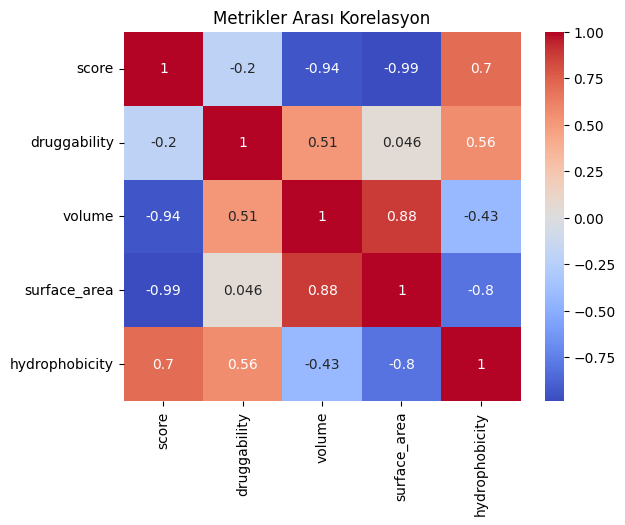

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sadece sayısal metrikleri seçiyoruz
metrics = df[['score', 'druggability', 'volume', 'surface_area', 'hydrophobicity']]
corr = metrics.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Metrikler Arası Korelasyon')
plt.savefig('korelasyon_heatmap.png')

/tmp/ipython-input-3547259588.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='mutation', y='volume', data=df, palette='magma')


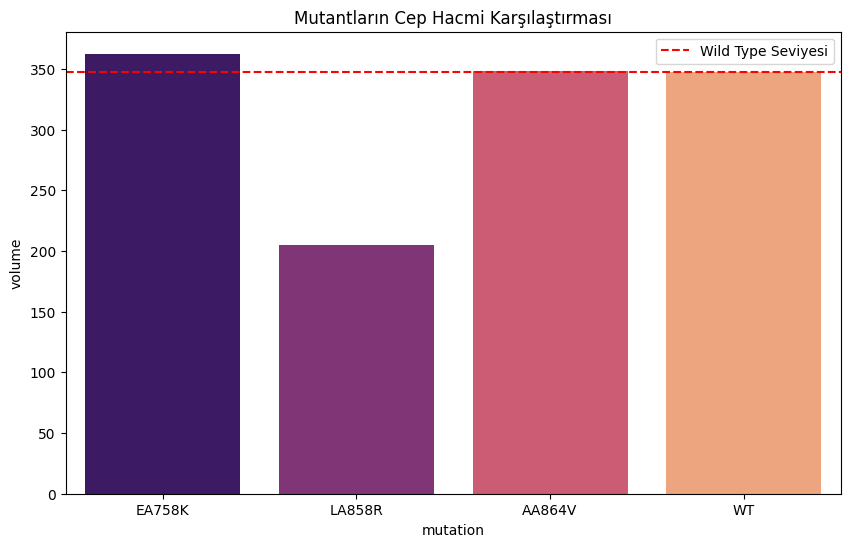

In [75]:
plt.figure(figsize=(10,6))
sns.barplot(x='mutation', y='volume', data=df, palette='magma')
# WT değerine bir referans çizgisi ekleyelim
wt_vol = df[df['mutation'] == 'WT']['volume'].values[0]
plt.axhline(wt_vol, color='red', linestyle='--', label='Wild Type Seviyesi')
plt.title('Mutantların Cep Hacmi Karşılaştırması')
plt.legend()
plt.savefig('hacim_karsilastirma.png')

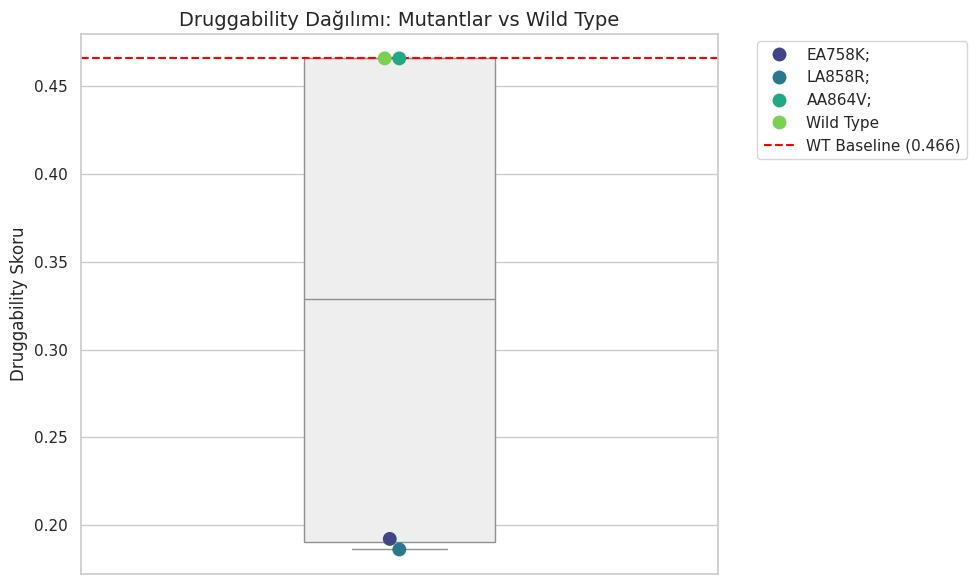

In [81]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Veriyi yükle
df = pd.read_csv("/content/pocket_full_metrics_with_mutation.csv")

# 2. Grafik stilini ayarla
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 3. Boxplot çiz (Genel dağılım için)
ax = sns.boxplot(y='druggability', data=df, color="#eeeeee", width=0.3)

# 4. Swarmplot ekle (Her bir mutasyonu nokta olarak görmek için)
# Mutasyon isimlerini noktaların yanına yazdırmak isterseniz:
sns.swarmplot(y='druggability', data=df, hue='mutation', palette='viridis', size=10)

# 5. WT Seviyesini işaretle (Kırmızı kesikli çizgi)
wt_val = df[df['mutation'] == 'Wild Type']['druggability'].values[0]
plt.axhline(wt_val, color='red', linestyle='--', label=f'WT Baseline ({wt_val})')

# Başlık ve etiketler
plt.title('Druggability Dağılımı: Mutantlar vs Wild Type', fontsize=14)
plt.ylabel('Druggability Skoru', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig("pocket_druggability_boxplot.png", dpi=300)
plt.show()

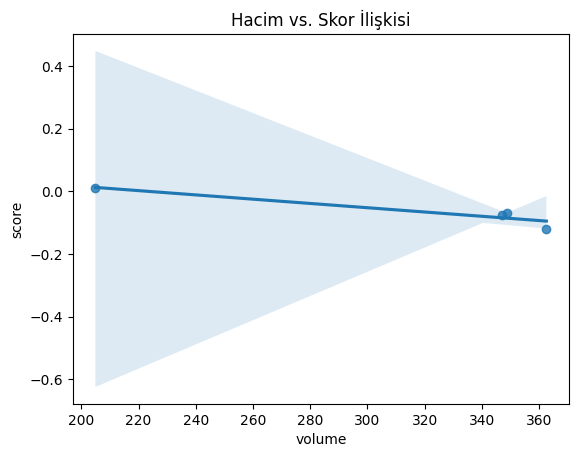

In [77]:
sns.regplot(x='volume', y='score', data=df)
plt.title('Hacim vs. Skor İlişkisi')
plt.savefig('hacim_skor_regresyon.png')

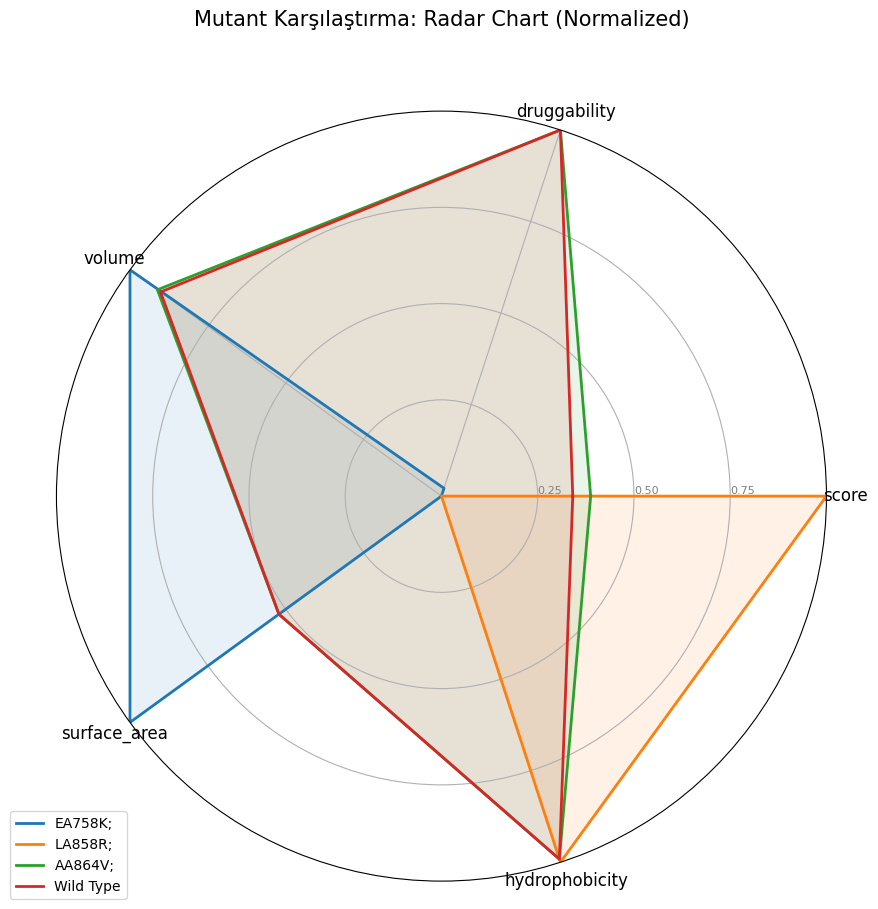

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import pi

# 1. Veriyi Yükle
df = pd.read_csv("/content/pocket_full_metrics_with_mutation.csv")

# 2. Analiz edilecek metrikleri belirle
metrics = ['score', 'druggability', 'volume', 'surface_area', 'hydrophobicity']

# 3. Normalizasyon (Tüm değerleri 0 ile 1 arasına getirir)
df_norm = df.copy()
for m in metrics:
    if df[m].max() != df[m].min():
        df_norm[m] = (df[m] - df[m].min()) / (df[m].max() - df[m].min())
    else:
        df_norm[m] = 1.0

# 4. Grafik Fonksiyonu
def draw_radar(df_norm, categories):
    N = len(categories)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

    # Her mutasyon için bir katman çiz
    for i, row in df_norm.iterrows():
        values = row[categories].values.flatten().tolist()
        values += values[:1]

        ax.plot(angles, values, linewidth=2, linestyle='solid', label=row['mutation'])
        ax.fill(angles, values, alpha=0.1)

    plt.xticks(angles[:-1], categories, color='black', size=12)
    ax.set_rlabel_position(0)
    plt.yticks([0.25, 0.5, 0.75], ["0.25", "0.50", "0.75"], color="grey", size=8)
    plt.ylim(0, 1)

    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
    plt.title("Mutant Karşılaştırma: Radar Chart (Normalized)", size=15, y=1.1)

    plt.savefig("radar_chart_mutations.png", bbox_inches='tight')
    plt.show()

# Grafiği Çiz
draw_radar(df_norm, metrics)

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV = "/content/pocket_disruption_delta.csv"
df = pd.read_csv(CSV)

# WT vs mutants ayrımı
wt = df[df["mutation"] == "WT"].copy()
mut = df[df["mutation"] != "WT"].copy()

df

,mutation,structure_out,best_pocket_id,dist_to_ligand,score,druggability,volume,surface_area,hydrophobicity,num_alpha_spheres,...,delta_surface_area,delta_hydrophobicity,delta_num_alpha_spheres,pct_score,pct_druggability,pct_volume,pct_surface_area,pct_hydrophobicity,pct_num_alpha_spheres,same_pocket_as_WT
0,WT,7SI1_clean_protein_only_out,11,3.045,-0.075,0.466,347.089,98.585,-0.857,24.0,...,0.000,0.000,0.0,-0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,True
1,EA758K,7SI1_clean_protein_only_1_out,18,3.045,-0.119,0.192,362.535,132.265,-3.625,29.0,...,33.680,-2.768,5.0,58.666667,-58.798283,4.450155,34.163412,322.987165,20.833333,False
2,LA858R,7SI1_clean_protein_only_2_out,11,2.845,0.010,0.186,204.946,61.823,-0.833,34.0,...,-36.762,0.024,10.0,-113.333333,-60.085837,-40.952897,-37.289649,-2.800467,41.666667,True
3,AA864V,7SI1_clean_protein_only_3_out,11,3.045,-0.069,0.466,348.641,98.585,-0.857,24.0,...,0.000,0.000,0.0,-8.000000,0.000000,0.447148,0.000000,-0.000000,0.000000,True


In [83]:
core_metrics = [
    "score", "druggability", "volume", "surface_area", "hydrophobicity", "num_alpha_spheres",
    "dist_to_ligand", "best_pocket_id", "same_pocket_as_WT"
]

summary_table = df[["mutation"] + [c for c in core_metrics if c in df.columns]].copy()
summary_table


,mutation,score,druggability,volume,surface_area,hydrophobicity,num_alpha_spheres,dist_to_ligand,best_pocket_id,same_pocket_as_WT
0,WT,-0.075,0.466,347.089,98.585,-0.857,24.0,3.045,11,True
1,EA758K,-0.119,0.192,362.535,132.265,-3.625,29.0,3.045,18,False
2,LA858R,0.010,0.186,204.946,61.823,-0.833,34.0,2.845,11,True
3,AA864V,-0.069,0.466,348.641,98.585,-0.857,24.0,3.045,11,True


In [84]:
delta_cols = [c for c in df.columns if c.startswith("delta_")]
delta_table = df[["mutation"] + delta_cols].copy()

# WT satırı zaten 0'a yakın olur, ister görün ister çıkarın
delta_table


,mutation,delta_score,delta_druggability,delta_volume,delta_surface_area,delta_hydrophobicity,delta_num_alpha_spheres
0,WT,0.000,0.000,0.000,0.000,0.000,0.0
1,EA758K,-0.044,-0.274,15.446,33.680,-2.768,5.0
2,LA858R,0.085,-0.280,-142.143,-36.762,0.024,10.0
3,AA864V,0.006,0.000,1.552,0.000,0.000,0.0


In [85]:
delta_table_no_wt = delta_table[delta_table["mutation"] != "WT"].copy()
delta_table_no_wt


,mutation,delta_score,delta_druggability,delta_volume,delta_surface_area,delta_hydrophobicity,delta_num_alpha_spheres
1,EA758K,-0.044,-0.274,15.446,33.680,-2.768,5.0
2,LA858R,0.085,-0.280,-142.143,-36.762,0.024,10.0
3,AA864V,0.006,0.000,1.552,0.000,0.000,0.0


In [86]:
pct_cols = [c for c in df.columns if c.startswith("pct_")]
pct_table = df[["mutation"] + pct_cols].copy()
pct_table


,mutation,pct_score,pct_druggability,pct_volume,pct_surface_area,pct_hydrophobicity,pct_num_alpha_spheres
0,WT,-0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000
1,EA758K,58.666667,-58.798283,4.450155,34.163412,322.987165,20.833333
2,LA858R,-113.333333,-60.085837,-40.952897,-37.289649,-2.800467,41.666667
3,AA864V,-8.000000,0.000000,0.447148,0.000000,-0.000000,0.000000


In [87]:
rank_metrics = ["delta_volume", "delta_surface_area", "delta_hydrophobicity", "delta_druggability", "delta_score"]
rank_metrics = [m for m in rank_metrics if m in df.columns]

rank_multi = df[df["mutation"] != "WT"][["mutation"] + rank_metrics].copy()
for m in rank_metrics:
    rank_multi[f"abs_{m}"] = rank_multi[m].abs()

# Her metrikte en büyük değişimi yapan mutasyonu bul
tops = []
for m in rank_metrics:
    idx = rank_multi[f"abs_{m}"].idxmax()
    tops.append({"metric": m, "top_mutation": rank_multi.loc[idx, "mutation"], "abs_change": rank_multi.loc[idx, f"abs_{m}"]})

pd.DataFrame(tops)


,metric,top_mutation,abs_change
0,delta_volume,LA858R,142.143
1,delta_surface_area,LA858R,36.762
2,delta_hydrophobicity,EA758K,2.768
3,delta_druggability,LA858R,0.280
4,delta_score,LA858R,0.085


In [88]:
corr_metrics = ["delta_volume", "delta_surface_area", "delta_hydrophobicity", "delta_druggability", "delta_score"]
corr_metrics = [m for m in corr_metrics if m in df.columns]

corr = df[df["mutation"] != "WT"][corr_metrics].corr(method="pearson")
corr


,delta_volume,delta_surface_area,delta_hydrophobicity,delta_druggability,delta_score
delta_volume,1.000000,0.913644,-0.573507,0.446320,-0.950851
delta_surface_area,0.913644,1.000000,-0.857000,0.043997,-0.994616
delta_hydrophobicity,-0.573507,-0.857000,1.000000,0.477112,0.798984
delta_druggability,0.446320,0.043997,0.477112,1.000000,-0.147289
delta_score,-0.950851,-0.994616,0.798984,-0.147289,1.000000


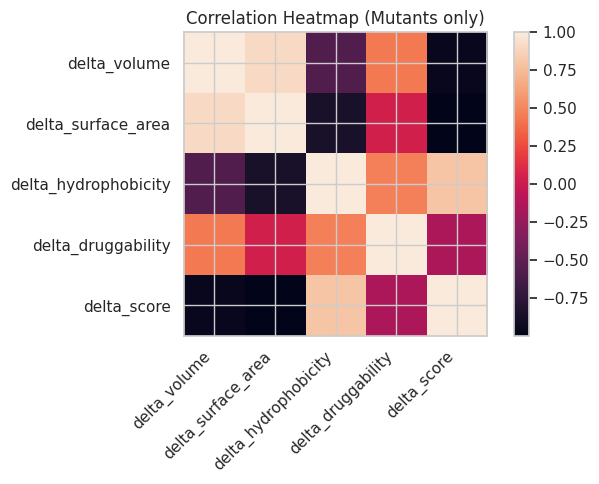

In [89]:
corr = corr.fillna(0)

plt.figure(figsize=(7,5))
plt.imshow(corr.values)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.colorbar()
plt.title("Correlation Heatmap (Mutants only)")
plt.tight_layout()
plt.show()


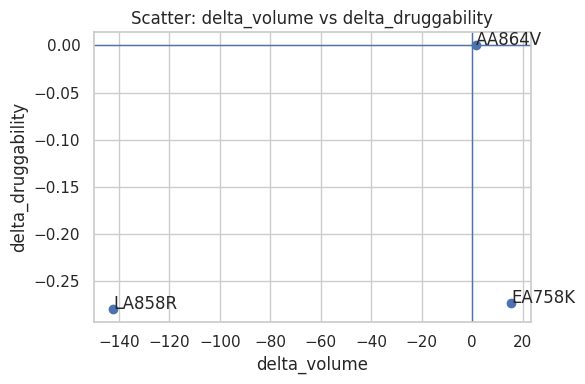

In [90]:
xcol, ycol = "delta_volume", "delta_druggability"

plot_df = df[df["mutation"] != "WT"].copy()

plt.figure(figsize=(6,4))
plt.scatter(plot_df[xcol], plot_df[ycol])
for _, r in plot_df.iterrows():
    plt.text(r[xcol], r[ycol], r["mutation"])
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel(xcol)
plt.ylabel(ycol)
plt.title(f"Scatter: {xcol} vs {ycol}")
plt.tight_layout()
plt.show()


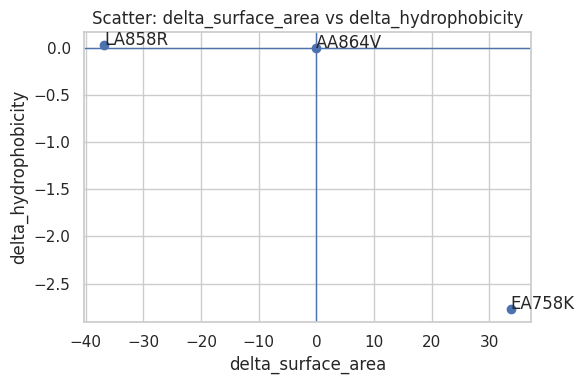

In [91]:
xcol, ycol = "delta_surface_area", "delta_hydrophobicity"
plot_df = df[df["mutation"] != "WT"].copy()

plt.figure(figsize=(6,4))
plt.scatter(plot_df[xcol], plot_df[ycol])
for _, r in plot_df.iterrows():
    plt.text(r[xcol], r[ycol], r["mutation"])
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel(xcol)
plt.ylabel(ycol)
plt.title(f"Scatter: {xcol} vs {ycol}")
plt.tight_layout()
plt.show()


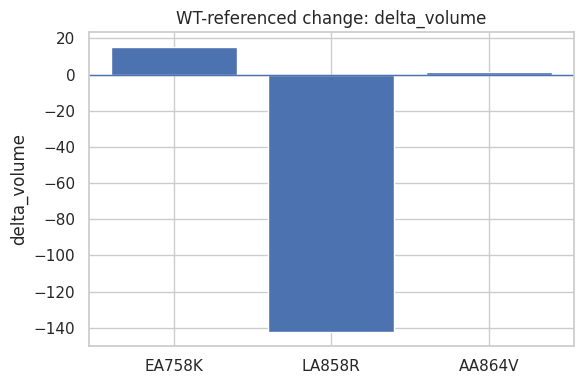

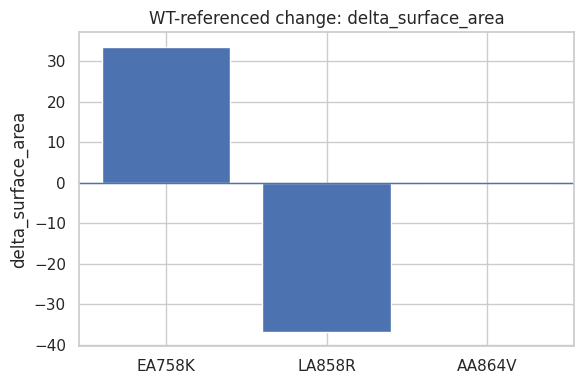

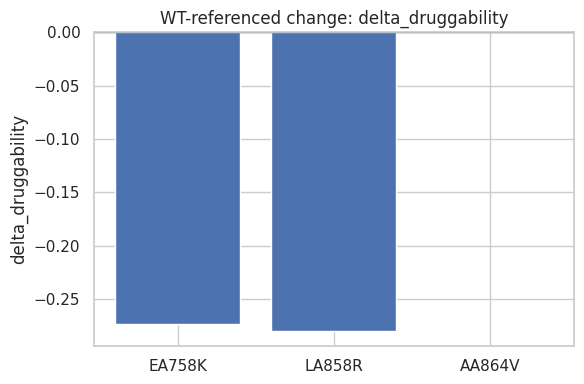

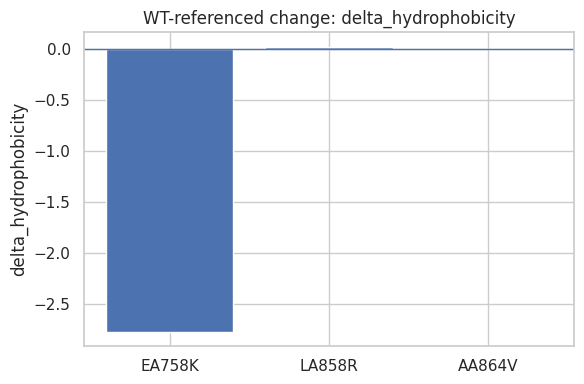

In [93]:
metrics_to_plot = ["delta_volume", "delta_surface_area", "delta_druggability", "delta_hydrophobicity"]
metrics_to_plot = [m for m in metrics_to_plot if m in df.columns]

for metric in metrics_to_plot:
    plot_df = df[df["mutation"] != "WT"].copy()
    plt.figure(figsize=(6,4))
    plt.bar(plot_df["mutation"], plot_df[metric])
    plt.axhline(0, linewidth=1)
    plt.ylabel(metric)
    plt.title(f"WT-referenced change: {metric}")
    plt.tight_layout()
    plt.show()


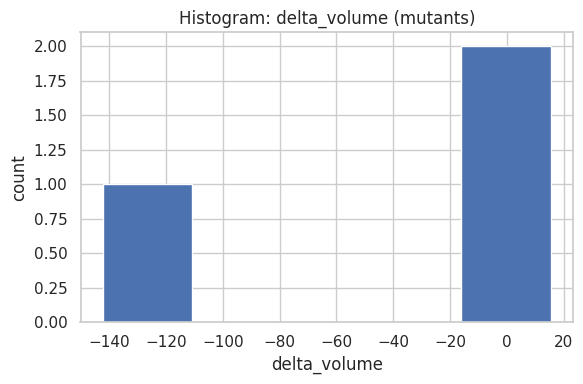

In [94]:
metric = "delta_volume"
vals = df[df["mutation"] != "WT"][metric].dropna().values

plt.figure(figsize=(6,4))
plt.hist(vals, bins=5)
plt.xlabel(metric)
plt.ylabel("count")
plt.title(f"Histogram: {metric} (mutants)")
plt.tight_layout()
plt.show()


/tmp/ipython-input-3208766361.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=metrics_for_box)


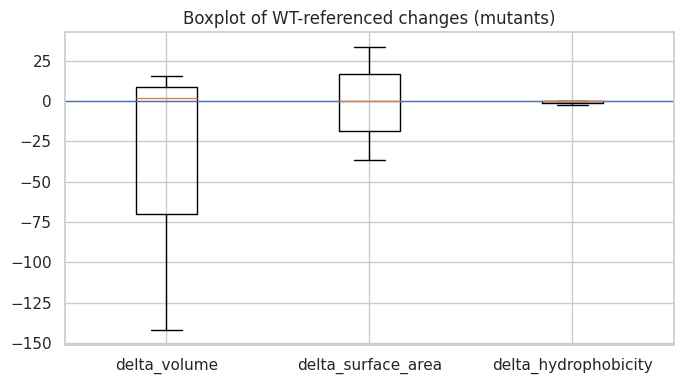

In [95]:
metrics_for_box = ["delta_volume", "delta_surface_area", "delta_hydrophobicity"]
metrics_for_box = [m for m in metrics_for_box if m in df.columns]

data = [df[df["mutation"] != "WT"][m].dropna().values for m in metrics_for_box]

plt.figure(figsize=(7,4))
plt.boxplot(data, labels=metrics_for_box)
plt.axhline(0, linewidth=1)
plt.title("Boxplot of WT-referenced changes (mutants)")
plt.tight_layout()
plt.show()


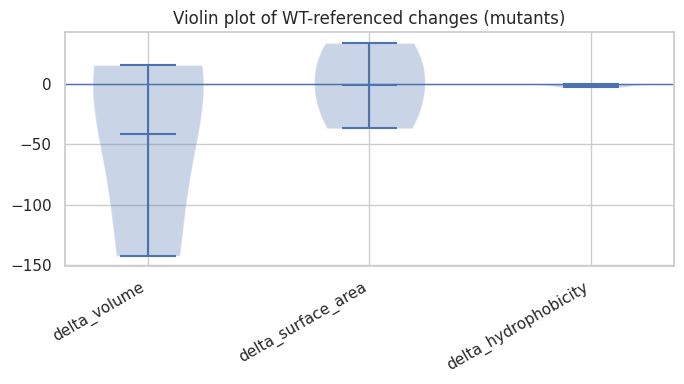

In [96]:
metrics_for_violin = ["delta_volume", "delta_surface_area", "delta_hydrophobicity"]
metrics_for_violin = [m for m in metrics_for_violin if m in df.columns]

data = [df[df["mutation"] != "WT"][m].dropna().values for m in metrics_for_violin]

plt.figure(figsize=(7,4))
plt.violinplot(data, showmeans=True, showextrema=True)
plt.xticks(range(1, len(metrics_for_violin)+1), metrics_for_violin, rotation=30, ha="right")
plt.axhline(0, linewidth=1)
plt.title("Violin plot of WT-referenced changes (mutants)")
plt.tight_layout()
plt.show()


In [97]:
# Mutants only
m = df[df["mutation"] != "WT"].copy()

z_metrics = ["delta_volume", "delta_surface_area", "delta_druggability", "delta_hydrophobicity", "delta_score"]
z_metrics = [c for c in z_metrics if c in m.columns]

z = m[["mutation"] + z_metrics].copy()
for col in z_metrics:
    mu = z[col].mean()
    sd = z[col].std(ddof=0)
    z[f"z_{col}"] = (z[col] - mu) / sd if sd != 0 else np.nan

z


,mutation,delta_volume,delta_surface_area,delta_druggability,delta_hydrophobicity,delta_score,z_delta_volume,z_delta_surface_area,z_delta_druggability,z_delta_hydrophobicity,z_delta_score
1,EA758K,15.446,33.680,-0.274,-2.768,-0.044,0.802378,1.206498,-0.684012,-1.414174,-1.123544
2,LA858R,-142.143,-36.762,-0.280,0.024,0.085,-1.409724,-1.242210,-0.729953,0.716244,1.305571
3,AA864V,1.552,0.000,0.000,0.000,0.006,0.607346,0.035712,1.413965,0.697930,-0.182027


In [116]:
import os

# === DOSYA LİSTESİ ===
input_pdbs = ["/content/EGFR_PDB_clean/7SI1_clean_protein_only.pdb"] + [
    f"/content/EGFR_PDB_clean/7SI1_clean_protein_only_{i}.pdb" for i in range(1, 4)
]

output_dir = "/content/clean"
os.makedirs(output_dir, exist_ok=True)

# === ELEMENT TAHMİNİ (AYNI KALDI) ===
def infer_element(atom_name):
    atom_name = atom_name.strip()

    if atom_name.startswith("C"):
        return "C"
    if atom_name.startswith("N"):
        return "N"
    if atom_name.startswith("O"):
        return "O"
    if atom_name.startswith("S"):
        return "S"
    if atom_name.startswith("H"):
        return "H"

    return atom_name[0].upper()

# === CLEAN FONKSİYONU ===
def clean_pdb(input_pdb, output_pdb):
    atom_serial = 1

    with open(input_pdb) as f, open(output_pdb, "w") as out:
        for line in f:
            if line.startswith(("ATOM", "HETATM")):
                atom_name = line[12:16]
                element = infer_element(atom_name)

                # PDB Formatına uygun kolon bazlı yazım
                out.write(
                    f"{line[:6]}"
                    f"{atom_serial:5d} "
                    f"{line[12:16]}"
                    f"{line[16:17]}"
                    f"{line[17:20]} "
                    f"{line[21:22]}"
                    f"{line[22:26]}"
                    f"{line[26:30]}"
                    f"{float(line[30:38]):8.3f}"
                    f"{float(line[38:46]):8.3f}"
                    f"{float(line[46:54]):8.3f}"
                    f"{float(line[54:60]):6.2f}"
                    f"{float(line[60:66]):6.2f}"
                    f"{'':10}"
                    f"{element:>2}\n"
                )
                atom_serial += 1

        out.write("TER\nEND\n")

# === TOPLU ÇALIŞTIR ===
for pdb in input_pdbs:
    if os.path.exists(pdb):
        out_name = os.path.basename(pdb).replace(".pdb", "_clean.pdb")
        out_path = os.path.join(output_dir, out_name)
        clean_pdb(pdb, out_path)
        print(f"✅ Cleaned: {out_name}")
    else:
        print(f"⚠️ Dosya bulunamadı: {pdb}")

print("\n🎯 Tüm WT + 4 mutasyon PDB clean edildi.")

✅ Cleaned: 7SI1_clean_protein_only_clean.pdb
✅ Cleaned: 7SI1_clean_protein_only_1_clean.pdb
✅ Cleaned: 7SI1_clean_protein_only_2_clean.pdb
✅ Cleaned: 7SI1_clean_protein_only_3_clean.pdb

🎯 Tüm WT + 17 mutasyon PDB clean edildi.


In [117]:
!apt-get install -y autodocktools

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Package autodocktools is not available, but is referred to by another package.
This may mean that the package is missing, has been obsoleted, or
is only available from another source

E: Package 'autodocktools' has no installation candidate


In [118]:
!apt-get install -y python2

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
python2 is already the newest version (2.7.18-3).
0 upgraded, 0 newly installed, 0 to remove and 33 not upgraded.


In [123]:
import os
import subprocess

# MGLTools içindeki hazırlık betiğinin yolu
PREPARE_RECEPTOR = "/usr/share/mgltools/MGLToolsPckgs/AutoDockTools/Utilities24/prepare_receptor4.py"

clean_dir = "/content/clean"
pdbqt_dir = "/content/pdbqt"
os.makedirs(pdbqt_dir, exist_ok=True)

# Temizlenmiş PDB dosyalarını listele
clean_pdbs = [f for f in os.listdir(clean_dir) if f.endswith("_clean.pdb")]

for pdb in clean_pdbs:
    input_pdb = os.path.join(clean_dir, pdb)
    output_pdbqt = os.path.join(
        pdbqt_dir, pdb.replace("_clean.pdb", ".pdbqt")
    )

    # AutoDockTools komutunu yapılandır
    # -A hydrogens: Sadece polar hidrojenlerin eklenmesini sağlar
    cmd = [
        "python2", PREPARE_RECEPTOR,
        "-r", input_pdb,
        "-o", output_pdbqt,
        "-A", "hydrogens"
    ]

    # Komutu çalıştır
    subprocess.run(cmd)
    print(f"✅ Receptor PDBQT üretildi: {output_pdbqt}")

print("\n🎯 TÜM WT + 4 MUTANT receptor pdbqt HAZIR")

✅ Receptor PDBQT üretildi: /content/pdbqt/7SI1_clean_protein_only.pdbqt
✅ Receptor PDBQT üretildi: /content/pdbqt/7SI1_clean_protein_only_1.pdbqt
✅ Receptor PDBQT üretildi: /content/pdbqt/7SI1_clean_protein_only_2.pdbqt
✅ Receptor PDBQT üretildi: /content/pdbqt/7SI1_clean_protein_only_3.pdbqt

🎯 TÜM WT + 4 MUTANT receptor pdbqt HAZIR


In [120]:
!apt-get update -qq
!apt-get install -y openbabel

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
openbabel is already the newest version (3.1.1+dfsg-6ubuntu5).
0 upgraded, 0 newly installed, 0 to remove and 33 not upgraded.


In [121]:

!apt-get update -qq
!apt-get install -y autodock-vina

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
autodock-vina is already the newest version (1.2.3-2).
0 upgraded, 0 newly installed, 0 to remove and 33 not upgraded.


In [122]:
!obabel -:"CO C1=C(C=C2C(=C1)N=CN=C2NC3=CC(=C(C=C3)F)Cl)OCCCN4CCOCC4" \
  -O /content/gefitinib.pdbqt \
  --gen3d

1 molecule converted


In [137]:
!obabel -ipdb  /content/clean/7SI1_clean_protein_only_clean.pdb  \
        -opdbqt -O /content/7SI1_clean_protein_only_clean.pdbqt \
        -xr -xh

*** Open Babel Warning  in PerceiveBondOrders
  Failed to kekulize aromatic bonds in OBMol::PerceiveBondOrders (title is /content/clean/7SI1_clean_protein_only_clean.pdb)

1 molecule converted


In [165]:
!vina \
 --receptor /content/7SI1_clean_protein_only_clean.pdbqt \
 --ligand /content/gefitinib.pdbqt \
 --center_x  49.16465759277344 \
 --center_y  5.823672771453857 \
 --center_z -21.610532760620117 \
 --size_x 24 \
 --size_y 24 \
 --size_z 24 \
 --exhaustiveness 32 \
 --out /content/gefitinib_7SI1_clean_protein_only_clean.pdbqt

AutoDock Vina v1.2.3
#################################################################
# If you used AutoDock Vina in your work, please cite:          #
#                                                               #
# J. Eberhardt, D. Santos-Martins, A. F. Tillack, and S. Forli  #
# AutoDock Vina 1.2.0: New Docking Methods, Expanded Force      #
# Field, and Python Bindings, J. Chem. Inf. Model. (2021)       #
# DOI 10.1021/acs.jcim.1c00203                                  #
#                                                               #
# O. Trott, A. J. Olson,                                        #
# AutoDock Vina: improving the speed and accuracy of docking    #
# with a new scoring function, efficient optimization and       #
# multithreading, J. Comp. Chem. (2010)                         #
# DOI 10.1002/jcc.21334                                         #
#                                                               #
# Please see https://github.com/ccsb-scripps/AutoDock-V

In [139]:
!obabel -ipdb  /content/clean/7SI1_clean_protein_only_1_clean.pdb  \
        -opdbqt -O /content/7SI1_clean_protein_only_1_clean.pdbqt \
        -xr -xh

*** Open Babel Warning  in PerceiveBondOrders
  Failed to kekulize aromatic bonds in OBMol::PerceiveBondOrders (title is /content/clean/7SI1_clean_protein_only_1_clean.pdb)

1 molecule converted


In [166]:
!vina \
 --receptor /content/7SI1_clean_protein_only_1_clean.pdbqt \
 --ligand /content/gefitinib.pdbqt \
 --center_x  49.16465759277344 \
 --center_y  5.823672771453857 \
 --center_z -21.610532760620117 \
 --size_x 24 \
 --size_y 24 \
 --size_z 24 \
 --exhaustiveness 32 \
 --out /content/gefitinib_7SI1_clean_protein_only_1_clean.pdbqt

AutoDock Vina v1.2.3
#################################################################
# If you used AutoDock Vina in your work, please cite:          #
#                                                               #
# J. Eberhardt, D. Santos-Martins, A. F. Tillack, and S. Forli  #
# AutoDock Vina 1.2.0: New Docking Methods, Expanded Force      #
# Field, and Python Bindings, J. Chem. Inf. Model. (2021)       #
# DOI 10.1021/acs.jcim.1c00203                                  #
#                                                               #
# O. Trott, A. J. Olson,                                        #
# AutoDock Vina: improving the speed and accuracy of docking    #
# with a new scoring function, efficient optimization and       #
# multithreading, J. Comp. Chem. (2010)                         #
# DOI 10.1002/jcc.21334                                         #
#                                                               #
# Please see https://github.com/ccsb-scripps/AutoDock-V

In [141]:
!obabel -ipdb  /content/clean/7SI1_clean_protein_only_2_clean.pdb  \
        -opdbqt -O /content/7SI1_clean_protein_only_2_clean.pdbqt \
        -xr -xh

*** Open Babel Warning  in PerceiveBondOrders
  Failed to kekulize aromatic bonds in OBMol::PerceiveBondOrders (title is /content/clean/7SI1_clean_protein_only_2_clean.pdb)

1 molecule converted


In [167]:
!vina \
 --receptor /content/7SI1_clean_protein_only_2_clean.pdbqt \
 --ligand /content/gefitinib.pdbqt \
 --center_x  49.16465759277344 \
 --center_y  5.823672771453857 \
 --center_z -21.610532760620117 \
 --size_x 24 \
 --size_y 24 \
 --size_z 24 \
 --exhaustiveness 32 \
 --out /content/gefitinib_7SI1_clean_protein_only_2_clean.pdbqt

AutoDock Vina v1.2.3
#################################################################
# If you used AutoDock Vina in your work, please cite:          #
#                                                               #
# J. Eberhardt, D. Santos-Martins, A. F. Tillack, and S. Forli  #
# AutoDock Vina 1.2.0: New Docking Methods, Expanded Force      #
# Field, and Python Bindings, J. Chem. Inf. Model. (2021)       #
# DOI 10.1021/acs.jcim.1c00203                                  #
#                                                               #
# O. Trott, A. J. Olson,                                        #
# AutoDock Vina: improving the speed and accuracy of docking    #
# with a new scoring function, efficient optimization and       #
# multithreading, J. Comp. Chem. (2010)                         #
# DOI 10.1002/jcc.21334                                         #
#                                                               #
# Please see https://github.com/ccsb-scripps/AutoDock-V

In [143]:
!obabel -ipdb  /content/clean/7SI1_clean_protein_only_3_clean.pdb  \
        -opdbqt -O /content/7SI1_clean_protein_only_3_clean.pdbqt \
        -xr -xh

*** Open Babel Warning  in PerceiveBondOrders
  Failed to kekulize aromatic bonds in OBMol::PerceiveBondOrders (title is /content/clean/7SI1_clean_protein_only_3_clean.pdb)

1 molecule converted


In [168]:
!vina \
 --receptor /content/7SI1_clean_protein_only_3_clean.pdbqt \
 --ligand /content/gefitinib.pdbqt \
 --center_x  49.16465759277344 \
 --center_y  5.823672771453857 \
 --center_z -21.610532760620117 \
 --size_x 24 \
 --size_y 24 \
 --size_z 24 \
 --exhaustiveness 32 \
 --out /content/gefitinib_7SI1_clean_protein_only_3_clean.pdbqt

AutoDock Vina v1.2.3
#################################################################
# If you used AutoDock Vina in your work, please cite:          #
#                                                               #
# J. Eberhardt, D. Santos-Martins, A. F. Tillack, and S. Forli  #
# AutoDock Vina 1.2.0: New Docking Methods, Expanded Force      #
# Field, and Python Bindings, J. Chem. Inf. Model. (2021)       #
# DOI 10.1021/acs.jcim.1c00203                                  #
#                                                               #
# O. Trott, A. J. Olson,                                        #
# AutoDock Vina: improving the speed and accuracy of docking    #
# with a new scoring function, efficient optimization and       #
# multithreading, J. Comp. Chem. (2010)                         #
# DOI 10.1002/jcc.21334                                         #
#                                                               #
# Please see https://github.com/ccsb-scripps/AutoDock-V

In [146]:
!obabel -:"CN(C)C/C=C/C(=O)NC1=CC2=C(C=C1OCC3CCOC3)N=CN=C2NC4=CC(=C(C=C4)F)Cl" \
  -O /content/afatinib.pdbqt \
  --gen3d

1 molecule converted


In [169]:
!vina \
 --receptor /content/7SI1_clean_protein_only_clean.pdbqt \
 --ligand /content/afatinib.pdbqt \
 --center_x  50.80290603637695 \
 --center_y  1.683515191078186 \
 --center_z  -20.391008377075195 \
 --size_x 24 \
 --size_y 24 \
 --size_z 24 \
 --exhaustiveness 32 \
 --out /content/afatinib_7SI1_clean_protein_only_clean.pdbqt

AutoDock Vina v1.2.3
#################################################################
# If you used AutoDock Vina in your work, please cite:          #
#                                                               #
# J. Eberhardt, D. Santos-Martins, A. F. Tillack, and S. Forli  #
# AutoDock Vina 1.2.0: New Docking Methods, Expanded Force      #
# Field, and Python Bindings, J. Chem. Inf. Model. (2021)       #
# DOI 10.1021/acs.jcim.1c00203                                  #
#                                                               #
# O. Trott, A. J. Olson,                                        #
# AutoDock Vina: improving the speed and accuracy of docking    #
# with a new scoring function, efficient optimization and       #
# multithreading, J. Comp. Chem. (2010)                         #
# DOI 10.1002/jcc.21334                                         #
#                                                               #
# Please see https://github.com/ccsb-scripps/AutoDock-V

In [170]:
!vina \
 --receptor /content/7SI1_clean_protein_only_1_clean.pdbqt \
 --ligand /content/afatinib.pdbqt \
 --center_x  50.80290603637695 \
 --center_y  1.683515191078186 \
 --center_z  -20.391008377075195 \
 --size_x 24 \
 --size_y 24 \
 --size_z 24 \
 --exhaustiveness 32 \
 --out /content/afatinib_7SI1_clean_protein_only_1_clean.pdbqt

AutoDock Vina v1.2.3
#################################################################
# If you used AutoDock Vina in your work, please cite:          #
#                                                               #
# J. Eberhardt, D. Santos-Martins, A. F. Tillack, and S. Forli  #
# AutoDock Vina 1.2.0: New Docking Methods, Expanded Force      #
# Field, and Python Bindings, J. Chem. Inf. Model. (2021)       #
# DOI 10.1021/acs.jcim.1c00203                                  #
#                                                               #
# O. Trott, A. J. Olson,                                        #
# AutoDock Vina: improving the speed and accuracy of docking    #
# with a new scoring function, efficient optimization and       #
# multithreading, J. Comp. Chem. (2010)                         #
# DOI 10.1002/jcc.21334                                         #
#                                                               #
# Please see https://github.com/ccsb-scripps/AutoDock-V

In [171]:
!vina \
 --receptor /content/7SI1_clean_protein_only_2_clean.pdbqt \
 --ligand /content/afatinib.pdbqt \
 --center_x  50.80290603637695 \
 --center_y  1.683515191078186 \
 --center_z  -20.391008377075195 \
 --size_x 24 \
 --size_y 24 \
 --size_z 24 \
 --exhaustiveness 32 \
 --out /content/afatinib_7SI1_clean_protein_only_2_clean.pdbqt

AutoDock Vina v1.2.3
#################################################################
# If you used AutoDock Vina in your work, please cite:          #
#                                                               #
# J. Eberhardt, D. Santos-Martins, A. F. Tillack, and S. Forli  #
# AutoDock Vina 1.2.0: New Docking Methods, Expanded Force      #
# Field, and Python Bindings, J. Chem. Inf. Model. (2021)       #
# DOI 10.1021/acs.jcim.1c00203                                  #
#                                                               #
# O. Trott, A. J. Olson,                                        #
# AutoDock Vina: improving the speed and accuracy of docking    #
# with a new scoring function, efficient optimization and       #
# multithreading, J. Comp. Chem. (2010)                         #
# DOI 10.1002/jcc.21334                                         #
#                                                               #
# Please see https://github.com/ccsb-scripps/AutoDock-V

In [172]:
!vina \
 --receptor /content/7SI1_clean_protein_only_3_clean.pdbqt \
 --ligand /content/afatinib.pdbqt \
 --center_x  50.80290603637695 \
 --center_y  1.683515191078186 \
 --center_z  -20.391008377075195 \
 --size_x 24 \
 --size_y 24 \
 --size_z 24 \
 --exhaustiveness 32 \
 --out /content/afatinib_7SI1_clean_protein_only_3_clean.pdbqt

AutoDock Vina v1.2.3
#################################################################
# If you used AutoDock Vina in your work, please cite:          #
#                                                               #
# J. Eberhardt, D. Santos-Martins, A. F. Tillack, and S. Forli  #
# AutoDock Vina 1.2.0: New Docking Methods, Expanded Force      #
# Field, and Python Bindings, J. Chem. Inf. Model. (2021)       #
# DOI 10.1021/acs.jcim.1c00203                                  #
#                                                               #
# O. Trott, A. J. Olson,                                        #
# AutoDock Vina: improving the speed and accuracy of docking    #
# with a new scoring function, efficient optimization and       #
# multithreading, J. Comp. Chem. (2010)                         #
# DOI 10.1002/jcc.21334                                         #
#                                                               #
# Please see https://github.com/ccsb-scripps/AutoDock-V

In [151]:
!obabel -:"CN(C)CCN(C)C1=C(C=C(C=C1)NC(=O)C=C)NC2=NC=CC(=N2)C3=CN(C4=CC=CC=C43)C" \
  -O /content/osimertinib.pdbqt \
  --gen3d

1 molecule converted


In [173]:
!vina \
 --receptor /content/7SI1_clean_protein_only_clean.pdbqt \
 --ligand /content/osimertinib.pdbqt \
 --center_x  49.46327209472656 \
 --center_y  0.949206531047821 \
 --center_z -17.31915855407715 \
 --size_x 24 \
 --size_y 24 \
 --size_z 24 \
 --exhaustiveness 32 \
 --out /content/osimertinib_7SI1_clean_protein_only_clean.pdbqt

AutoDock Vina v1.2.3
#################################################################
# If you used AutoDock Vina in your work, please cite:          #
#                                                               #
# J. Eberhardt, D. Santos-Martins, A. F. Tillack, and S. Forli  #
# AutoDock Vina 1.2.0: New Docking Methods, Expanded Force      #
# Field, and Python Bindings, J. Chem. Inf. Model. (2021)       #
# DOI 10.1021/acs.jcim.1c00203                                  #
#                                                               #
# O. Trott, A. J. Olson,                                        #
# AutoDock Vina: improving the speed and accuracy of docking    #
# with a new scoring function, efficient optimization and       #
# multithreading, J. Comp. Chem. (2010)                         #
# DOI 10.1002/jcc.21334                                         #
#                                                               #
# Please see https://github.com/ccsb-scripps/AutoDock-V

In [174]:
!vina \
 --receptor /content/7SI1_clean_protein_only_1_clean.pdbqt \
 --ligand /content/osimertinib.pdbqt \
 --center_x  49.46327209472656 \
 --center_y  0.949206531047821 \
 --center_z -17.31915855407715 \
 --size_x 24 \
 --size_y 24 \
 --size_z 24 \
 --exhaustiveness 32 \
 --out /content/osimertinib_7SI1_clean_protein_only_1_clean.pdbqt

AutoDock Vina v1.2.3
#################################################################
# If you used AutoDock Vina in your work, please cite:          #
#                                                               #
# J. Eberhardt, D. Santos-Martins, A. F. Tillack, and S. Forli  #
# AutoDock Vina 1.2.0: New Docking Methods, Expanded Force      #
# Field, and Python Bindings, J. Chem. Inf. Model. (2021)       #
# DOI 10.1021/acs.jcim.1c00203                                  #
#                                                               #
# O. Trott, A. J. Olson,                                        #
# AutoDock Vina: improving the speed and accuracy of docking    #
# with a new scoring function, efficient optimization and       #
# multithreading, J. Comp. Chem. (2010)                         #
# DOI 10.1002/jcc.21334                                         #
#                                                               #
# Please see https://github.com/ccsb-scripps/AutoDock-V

In [175]:
!vina \
 --receptor /content/7SI1_clean_protein_only_2_clean.pdbqt \
 --ligand /content/osimertinib.pdbqt \
 --center_x  49.46327209472656 \
 --center_y  0.949206531047821 \
 --center_z -17.31915855407715 \
 --size_x 24 \
 --size_y 24 \
 --size_z 24 \
 --exhaustiveness 32 \
 --out /content/osimertinib_7SI1_clean_protein_only_2_clean.pdbqt

AutoDock Vina v1.2.3
#################################################################
# If you used AutoDock Vina in your work, please cite:          #
#                                                               #
# J. Eberhardt, D. Santos-Martins, A. F. Tillack, and S. Forli  #
# AutoDock Vina 1.2.0: New Docking Methods, Expanded Force      #
# Field, and Python Bindings, J. Chem. Inf. Model. (2021)       #
# DOI 10.1021/acs.jcim.1c00203                                  #
#                                                               #
# O. Trott, A. J. Olson,                                        #
# AutoDock Vina: improving the speed and accuracy of docking    #
# with a new scoring function, efficient optimization and       #
# multithreading, J. Comp. Chem. (2010)                         #
# DOI 10.1002/jcc.21334                                         #
#                                                               #
# Please see https://github.com/ccsb-scripps/AutoDock-V

In [176]:
!vina \
 --receptor /content/7SI1_clean_protein_only_3_clean.pdbqt \
 --ligand /content/osimertinib.pdbqt \
 --center_x  49.46327209472656 \
 --center_y  0.949206531047821 \
 --center_z -17.31915855407715 \
 --size_x 24 \
 --size_y 24 \
 --size_z 24 \
 --exhaustiveness 32 \
 --out /content/osimertinib_7SI1_clean_protein_only_3_clean.pdbqt

AutoDock Vina v1.2.3
#################################################################
# If you used AutoDock Vina in your work, please cite:          #
#                                                               #
# J. Eberhardt, D. Santos-Martins, A. F. Tillack, and S. Forli  #
# AutoDock Vina 1.2.0: New Docking Methods, Expanded Force      #
# Field, and Python Bindings, J. Chem. Inf. Model. (2021)       #
# DOI 10.1021/acs.jcim.1c00203                                  #
#                                                               #
# O. Trott, A. J. Olson,                                        #
# AutoDock Vina: improving the speed and accuracy of docking    #
# with a new scoring function, efficient optimization and       #
# multithreading, J. Comp. Chem. (2010)                         #
# DOI 10.1002/jcc.21334                                         #
#                                                               #
# Please see https://github.com/ccsb-scripps/AutoDock-V

In [156]:
# Generate a 3D structure from the given SMILES string and convert it to PDBQT format
# -:"SMILES"     : Input molecule in SMILES notation (erlotinib)
# -O             : Output file in PDBQT format
# --gen3d        : Generate 3D coordinates for the molecule

!obabel -:"COC1=CC=C(C=C1)NC2=NC=NC3=CC(=C(C=C23)C#C)OC" \
  -O /content/erlotinib.pdbqt \
  --gen3d


1 molecule converted


In [161]:
!vina \
 --receptor /content/7SI1_clean_protein_only_clean.pdbqt \
 --ligand /content/erlotinib.pdbqt \
 --center_x 50.814 \
 --center_y 0.575 \
 --center_z -20.139 \
 --size_x 24 \
 --size_y 24 \
 --size_z 24 \
 --exhaustiveness 32 \
 --out /content/erlotinib_7SI1_clean_protein_only_clean.pdbqt


AutoDock Vina v1.2.3
#################################################################
# If you used AutoDock Vina in your work, please cite:          #
#                                                               #
# J. Eberhardt, D. Santos-Martins, A. F. Tillack, and S. Forli  #
# AutoDock Vina 1.2.0: New Docking Methods, Expanded Force      #
# Field, and Python Bindings, J. Chem. Inf. Model. (2021)       #
# DOI 10.1021/acs.jcim.1c00203                                  #
#                                                               #
# O. Trott, A. J. Olson,                                        #
# AutoDock Vina: improving the speed and accuracy of docking    #
# with a new scoring function, efficient optimization and       #
# multithreading, J. Comp. Chem. (2010)                         #
# DOI 10.1002/jcc.21334                                         #
#                                                               #
# Please see https://github.com/ccsb-scripps/AutoDock-V

In [162]:
!vina \
 --receptor /content/7SI1_clean_protein_only_1_clean.pdbqt \
 --ligand /content/erlotinib.pdbqt \
 --center_x 50.814 \
 --center_y 0.575 \
 --center_z -20.139 \
 --size_x 24 \
 --size_y 24 \
 --size_z 24 \
 --exhaustiveness 32 \
 --out /content/erlotinib_7SI1_clean_protein_only_1_clean.pdbqt

AutoDock Vina v1.2.3
#################################################################
# If you used AutoDock Vina in your work, please cite:          #
#                                                               #
# J. Eberhardt, D. Santos-Martins, A. F. Tillack, and S. Forli  #
# AutoDock Vina 1.2.0: New Docking Methods, Expanded Force      #
# Field, and Python Bindings, J. Chem. Inf. Model. (2021)       #
# DOI 10.1021/acs.jcim.1c00203                                  #
#                                                               #
# O. Trott, A. J. Olson,                                        #
# AutoDock Vina: improving the speed and accuracy of docking    #
# with a new scoring function, efficient optimization and       #
# multithreading, J. Comp. Chem. (2010)                         #
# DOI 10.1002/jcc.21334                                         #
#                                                               #
# Please see https://github.com/ccsb-scripps/AutoDock-V

In [163]:
!vina \
 --receptor /content/7SI1_clean_protein_only_2_clean.pdbqt \
 --ligand /content/erlotinib.pdbqt \
 --center_x 50.814 \
 --center_y 0.575 \
 --center_z -20.139 \
 --size_x 24 \
 --size_y 24 \
 --size_z 24 \
 --exhaustiveness 32 \
 --out /content/erlotinib_7SI1_clean_protein_only_2_clean.pdbqt

AutoDock Vina v1.2.3
#################################################################
# If you used AutoDock Vina in your work, please cite:          #
#                                                               #
# J. Eberhardt, D. Santos-Martins, A. F. Tillack, and S. Forli  #
# AutoDock Vina 1.2.0: New Docking Methods, Expanded Force      #
# Field, and Python Bindings, J. Chem. Inf. Model. (2021)       #
# DOI 10.1021/acs.jcim.1c00203                                  #
#                                                               #
# O. Trott, A. J. Olson,                                        #
# AutoDock Vina: improving the speed and accuracy of docking    #
# with a new scoring function, efficient optimization and       #
# multithreading, J. Comp. Chem. (2010)                         #
# DOI 10.1002/jcc.21334                                         #
#                                                               #
# Please see https://github.com/ccsb-scripps/AutoDock-V

In [164]:
!vina \
 --receptor /content/7SI1_clean_protein_only_3_clean.pdbqt \
 --ligand /content/erlotinib.pdbqt \
 --center_x 50.814 \
 --center_y 0.575 \
 --center_z -20.139 \
 --size_x 24 \
 --size_y 24 \
 --size_z 24 \
 --exhaustiveness 32 \
 --out /content/erlotinib_7SI1_clean_protein_only_3_clean.pdbqt

AutoDock Vina v1.2.3
#################################################################
# If you used AutoDock Vina in your work, please cite:          #
#                                                               #
# J. Eberhardt, D. Santos-Martins, A. F. Tillack, and S. Forli  #
# AutoDock Vina 1.2.0: New Docking Methods, Expanded Force      #
# Field, and Python Bindings, J. Chem. Inf. Model. (2021)       #
# DOI 10.1021/acs.jcim.1c00203                                  #
#                                                               #
# O. Trott, A. J. Olson,                                        #
# AutoDock Vina: improving the speed and accuracy of docking    #
# with a new scoring function, efficient optimization and       #
# multithreading, J. Comp. Chem. (2010)                         #
# DOI 10.1002/jcc.21334                                         #
#                                                               #
# Please see https://github.com/ccsb-scripps/AutoDock-V

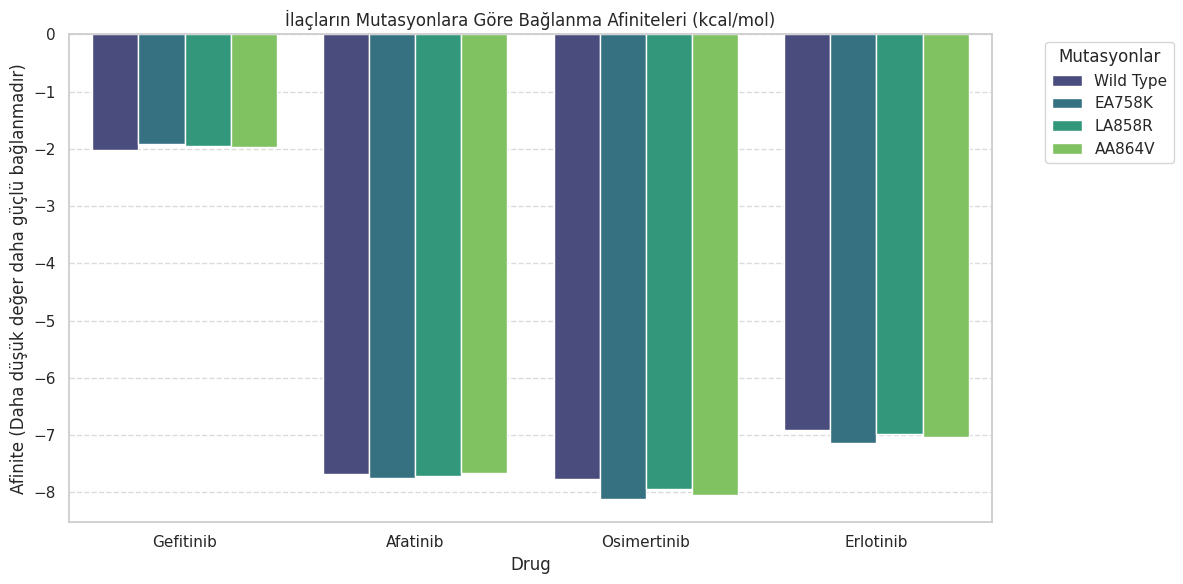

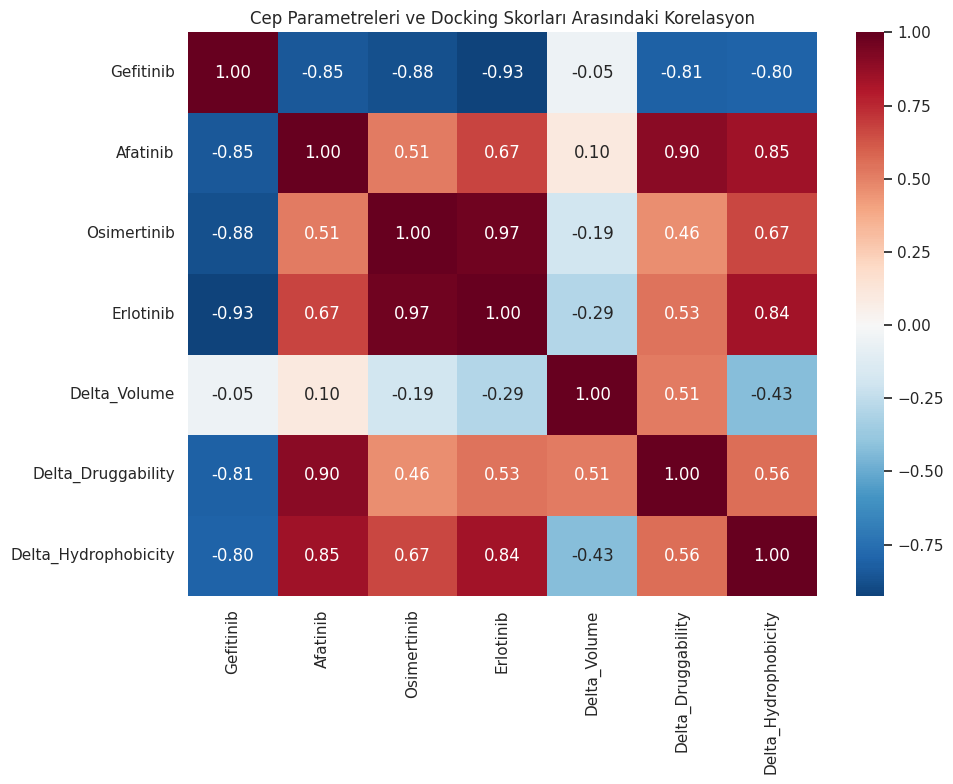

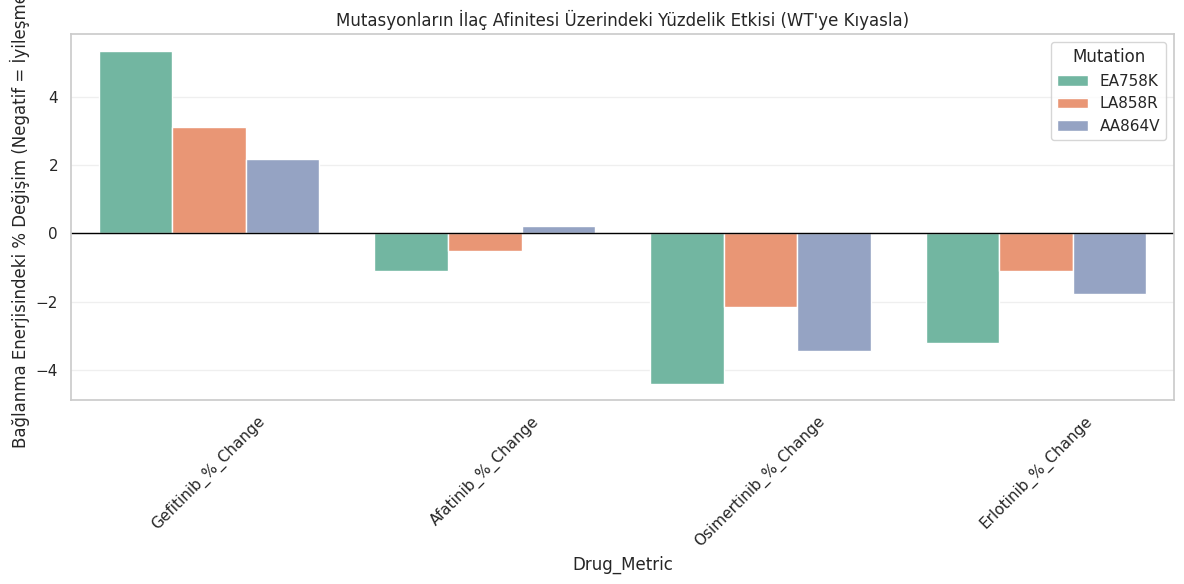

Analiz tamamlandı ve 'docking_analiz_ozeti.csv' dosyası oluşturuldu.


In [188]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. VERİ HAZIRLAMA
# Notebook çıktılarından elde edilen Docking skorları (kcal/mol)
# Not: Vina sonuçlarında daha düşük (negatif) değer daha iyi bağlanmayı ifade eder.
docking_data = {
    'Mutation': ['Wild Type', 'EA758K', 'LA858R', 'AA864V'],
    'Gefitinib': [-2.016, -1.908, -1.953, -1.972],
    'Afatinib': [-7.675, -7.759, -7.715, -7.659],
    'Osimertinib': [-7.777, -8.120, -7.944, -8.045],
    'Erlotinib': [-6.913, -7.136, -6.990, -7.037]
}

# Pocket metrik değişimleri (Önceki analiz hücrelerinden alınan delta değerleri)
pocket_delta_data = {
    'Mutation': ['Wild Type', 'EA758K', 'LA858R', 'AA864V'],
    'Delta_Volume': [0.000, 15.446, -142.143, 1.552],
    'Delta_Druggability': [0.000, -0.274, -0.280, 0.000],
    'Delta_Hydrophobicity': [0.000, -2.768, 0.024, 0.000]
}

df_docking = pd.DataFrame(docking_data)
df_pocket = pd.DataFrame(pocket_delta_data)

# Verileri birleştirme
df_merged = pd.merge(df_docking, df_pocket, on='Mutation')

# 2. ORANLARIN HESAPLANMASI (% Değişim vs Wild Type)
drugs = ['Gefitinib', 'Afatinib', 'Osimertinib', 'Erlotinib']
for drug in drugs:
    wt_val = df_merged.loc[df_merged['Mutation'] == 'Wild Type', drug].values[0]
    # % değişim formülü: ((Mutant - WT) / |WT|) * 100
    df_merged[f'{drug}_%_Change'] = (df_merged[drug] - wt_val) / abs(wt_val) * 100

# 3. GÖRSELLEŞTİRME

# Grafik 1: Docking Afiniteleri Karşılaştırması
plt.figure(figsize=(12, 6))
df_long = pd.melt(df_merged, id_vars=['Mutation'], value_vars=drugs,
                  var_name='Drug', value_name='Affinity')
sns.barplot(data=df_long, x='Drug', y='Affinity', hue='Mutation', palette='viridis')
plt.title('İlaçların Mutasyonlara Göre Bağlanma Afiniteleri (kcal/mol)')
plt.ylabel('Afinite (Daha düşük değer daha güçlü bağlanmadır)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Mutasyonlar', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Grafik 2: Korelasyon Heatmap (Cep Değişimleri vs Docking Skorları)
plt.figure(figsize=(10, 8))
# Sadece sayısal sütunları alalım
corr_cols = drugs + ['Delta_Volume', 'Delta_Druggability', 'Delta_Hydrophobicity']
correlation_matrix = df_merged[corr_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title('Cep Parametreleri ve Docking Skorları Arasındaki Korelasyon')
plt.tight_layout()
plt.show()

# Grafik 3: Wild Type'a Göre Değişim Oranları (%)
pct_cols = [f'{drug}_%_Change' for drug in drugs]
df_pct_long = pd.melt(df_merged[df_merged['Mutation'] != 'Wild Type'],
                      id_vars=['Mutation'], value_vars=pct_cols,
                      var_name='Drug_Metric', value_name='Percent_Change')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_pct_long, x='Drug_Metric', y='Percent_Change', hue='Mutation', palette='Set2')
plt.axhline(0, color='black', linewidth=1)
plt.title('Mutasyonların İlaç Afinitesi Üzerindeki Yüzdelik Etkisi (WT\'ye Kıyasla)')
plt.ylabel('Bağlanma Enerjisindeki % Değişim (Negatif = İyileşme)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 4. SONUÇLARIN KAYDEDİLMESİ
df_merged.to_csv('docking_analiz_ozeti.csv', index=False)
print("Analiz tamamlandı ve 'docking_analiz_ozeti.csv' dosyası oluşturuldu.")

In [190]:
"""
EGFR Mutation Docking Analysis and Visualization Script
========================================================
This script analyzes molecular docking results for EGFR protein variants
(Wild Type and 3 mutations) with 4 different drugs:
- Gefitinib (1st generation TKI)
- Erlotinib (1st generation TKI)
- Afatinib (2nd generation TKI)
- Osimertinib (3rd generation TKI)

Pocket metrics changes (volume, druggability, hydrophobicity, etc.)
are correlated with docking scores to understand mutation effects.
"""

import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')  # Non-interactive backend for saving figures
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for publication-quality figures
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['legend.fontsize'] = 11

# ============================================
# 1. DATA PREPARATION - DOCKING RESULTS
# ============================================

# Docking scores from AutoDock Vina (kcal/mol)
# Note: More negative values indicate stronger binding

# Gefitinib docking results (from notebook)
gefitinib_scores = {
    'WT': -2.016,
    'EA758K': -1.908,
    'LA858R': -1.953,
    'AA864V': -1.972
}

# Afatinib docking results
afatinib_scores = {
    'WT': -7.675,
    'EA758K': -7.759,
    'LA858R': -7.715,
    'AA864V': -7.659
}

# Osimertinib docking results
osimertinib_scores = {
    'WT': -7.777,
    'EA758K': -8.120,
    'LA858R': -7.944,
    'AA864V': -8.045
}

# Erlotinib docking results
erlotinib_scores = {
    'WT': -6.913,
    'EA758K': -7.136,
    'LA858R': -6.990,
    'AA864V': -7.037
}

# Create main docking DataFrame
docking_data = pd.DataFrame({
    'Mutation': ['WT', 'EA758K', 'LA858R', 'AA864V'],
    'Gefitinib': [gefitinib_scores['WT'], gefitinib_scores['EA758K'],
                  gefitinib_scores['LA858R'], gefitinib_scores['AA864V']],
    'Afatinib': [afatinib_scores['WT'], afatinib_scores['EA758K'],
                 afatinib_scores['LA858R'], afatinib_scores['AA864V']],
    'Osimertinib': [osimertinib_scores['WT'], osimertinib_scores['EA758K'],
                    osimertinib_scores['LA858R'], osimertinib_scores['AA864V']],
    'Erlotinib': [erlotinib_scores['WT'], erlotinib_scores['EA758K'],
                  erlotinib_scores['LA858R'], erlotinib_scores['AA864V']]
})

# ============================================
# 2. POCKET METRICS DATA
# ============================================

# Delta values (changes compared to Wild Type)
pocket_delta_data = pd.DataFrame({
    'Mutation': ['WT', 'EA758K', 'LA858R', 'AA864V'],
    'Delta_Volume': [0.000, 15.446, -142.143, 1.552],
    'Delta_Druggability': [0.000, -0.274, -0.280, 0.000],
    'Delta_Hydrophobicity': [0.000, -2.768, 0.024, 0.000],
    'Delta_Surface_Area': [0.000, 33.680, -36.762, 0.000],
    'Delta_Num_Alpha_Spheres': [0.0, 5.0, 10.0, 0.0]
})

# Absolute pocket metrics values
pocket_absolute_data = pd.DataFrame({
    'Mutation': ['WT', 'EA758K', 'LA858R', 'AA864V'],
    'Volume': [347.089, 362.535, 204.946, 348.641],
    'Druggability': [0.466, 0.192, 0.186, 0.466],
    'Surface_Area': [98.585, 132.265, 61.823, 98.585],
    'Hydrophobicity': [-0.857, -3.625, -0.833, -0.857],
    'Num_Alpha_Spheres': [24.0, 29.0, 34.0, 24.0]
})

# Merge datasets
df_merged = pd.merge(docking_data, pocket_delta_data, on='Mutation')
df_full = pd.merge(df_merged, pocket_absolute_data, on='Mutation')

# ============================================
# 3. CALCULATE PERCENTAGE CHANGES
# ============================================

drugs = ['Gefitinib', 'Afatinib', 'Osimertinib', 'Erlotinib']
for drug in drugs:
    wt_val = df_full.loc[df_full['Mutation'] == 'WT', drug].values[0]
    # % change: ((Mutant - WT) / |WT|) * 100
    df_full[f'{drug}_Pct_Change'] = (df_full[drug] - wt_val) / abs(wt_val) * 100

# ============================================
# 4. STATISTICAL ANALYSIS
# ============================================

def perform_correlation_analysis(df, drugs, metrics):
    """Calculate correlations between docking scores and pocket metrics."""
    results = []
    for drug in drugs:
        for metric in metrics:
            corr, p_val = stats.pearsonr(df[drug], df[metric])
            results.append({
                'Drug': drug,
                'Metric': metric,
                'Correlation': corr,
                'P_Value': p_val
            })
    return pd.DataFrame(results)

delta_metrics = ['Delta_Volume', 'Delta_Druggability', 'Delta_Hydrophobicity',
                 'Delta_Surface_Area', 'Delta_Num_Alpha_Spheres']
absolute_metrics = ['Volume', 'Druggability', 'Surface_Area', 'Hydrophobicity',
                    'Num_Alpha_Spheres']

corr_delta = perform_correlation_analysis(df_full, drugs, delta_metrics)
corr_absolute = perform_correlation_analysis(df_full, drugs, absolute_metrics)

# ============================================
# 5. VISUALIZATION FUNCTIONS
# ============================================

def plot_docking_comparison(df, drugs, save_path='docking_comparison.png'):
    """Bar plot comparing docking scores across mutations for all drugs."""
    fig, ax = plt.subplots(figsize=(14, 8))

    df_long = pd.melt(df, id_vars=['Mutation'], value_vars=drugs,
                      var_name='Drug', value_name='Affinity')

    colors = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6']
    bar_plot = sns.barplot(data=df_long, x='Drug', y='Affinity', hue='Mutation',
                           palette='viridis', ax=ax)

    ax.set_title('Binding Affinity Comparison Across EGFR Variants\n(More negative = stronger binding)',
                 fontsize=16, fontweight='bold')
    ax.set_xlabel('Drug', fontsize=14)
    ax.set_ylabel('Binding Affinity (kcal/mol)', fontsize=14)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax.legend(title='EGFR Variant', bbox_to_anchor=(1.02, 1), loc='upper left')

    # Add value labels on bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', fontsize=9, padding=2)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

def plot_heatmap_correlation(df, drugs, metrics, title, save_path):
    """Heatmap of correlations between docking scores and metrics."""
    corr_matrix = pd.DataFrame(index=drugs, columns=metrics)
    for drug in drugs:
        for metric in metrics:
            corr, _ = stats.pearsonr(df[drug], df[metric])
            corr_matrix.loc[drug, metric] = corr

    corr_matrix = corr_matrix.astype(float)

    fig, ax = plt.subplots(figsize=(12, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0,
                fmt='.3f', linewidths=0.5, ax=ax,
                cbar_kws={'label': 'Pearson Correlation'})
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.set_xlabel('Pocket Metrics', fontsize=14)
    ax.set_ylabel('Drug', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

def plot_percent_change(df, drugs, save_path='percent_change.png'):
    """Bar plot showing percentage change in binding affinity vs WT."""
    pct_cols = [f'{drug}_Pct_Change' for drug in drugs]
    df_mutants = df[df['Mutation'] != 'WT'].copy()

    df_pct_long = pd.melt(df_mutants, id_vars=['Mutation'], value_vars=pct_cols,
                          var_name='Drug', value_name='Pct_Change')
    df_pct_long['Drug'] = df_pct_long['Drug'].str.replace('_Pct_Change', '')

    fig, ax = plt.subplots(figsize=(14, 8))
    bar_plot = sns.barplot(data=df_pct_long, x='Drug', y='Pct_Change',
                           hue='Mutation', palette='Set2', ax=ax)

    ax.axhline(y=0, color='black', linewidth=1.5)
    ax.set_title('Percentage Change in Binding Affinity vs Wild Type\n(Negative = Improved binding)',
                 fontsize=16, fontweight='bold')
    ax.set_xlabel('Drug', fontsize=14)
    ax.set_ylabel('Binding Affinity Change (%)', fontsize=14)
    ax.legend(title='Mutation', bbox_to_anchor=(1.02, 1), loc='upper left')

    # Add value labels
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', fontsize=9, padding=2)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

def plot_pocket_metrics_delta(df, save_path='pocket_delta.png'):
    """Plot pocket metric changes for each mutation."""
    delta_cols = ['Delta_Volume', 'Delta_Druggability', 'Delta_Surface_Area', 'Delta_Hydrophobicity']
    df_mutants = df[df['Mutation'] != 'WT'].copy()

    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()

    colors = {'EA758K': '#e74c3c', 'LA858R': '#3498db', 'AA864V': '#2ecc71'}

    for i, col in enumerate(delta_cols):
        ax = axes[i]
        mutations = df_mutants['Mutation']
        values = df_mutants[col]

        bars = ax.bar(mutations, values, color=[colors[m] for m in mutations])
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
        ax.set_title(col.replace('Delta_', 'Δ ').replace('_', ' '), fontsize=14, fontweight='bold')
        ax.set_ylabel('Change vs Wild Type')

        # Add value labels
        for bar, val in zip(bars, values):
            y_offset = 3 if val >= 0 else -15
            ax.annotate(f'{val:.2f}', xy=(bar.get_x() + bar.get_width()/2, val),
                       ha='center', va='bottom' if val >= 0 else 'top',
                       fontsize=11, fontweight='bold')

    plt.suptitle('Pocket Metric Changes Due to EGFR Mutations',
                 fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

def plot_drug_mutation_heatmap(df, drugs, save_path='drug_mutation_heatmap.png'):
    """Heatmap of docking scores for drug-mutation combinations."""
    matrix = df.set_index('Mutation')[drugs]

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(matrix, annot=True, cmap='RdYlGn_r', fmt='.2f',
                linewidths=1, ax=ax,
                cbar_kws={'label': 'Binding Affinity (kcal/mol)'})
    ax.set_title('Docking Scores: Drug vs EGFR Variant\n(More negative = stronger binding)',
                 fontsize=16, fontweight='bold')
    ax.set_xlabel('Drug', fontsize=14)
    ax.set_ylabel('EGFR Variant', fontsize=14)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

def plot_radar_chart(df, drugs, save_path='radar_chart.png'):
    """Radar chart comparing drug efficacy across mutations."""
    from math import pi

    # Normalize scores (make positive for radar chart, larger = better)
    normalized_data = {}
    for drug in drugs:
        values = df[drug].values
        # Invert because more negative is better
        normalized_data[drug] = -values

    mutations = df['Mutation'].tolist()
    categories = mutations
    N = len(categories)

    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

    colors = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6']

    for i, drug in enumerate(drugs):
        values = normalized_data[drug].tolist()
        values += values[:1]
        ax.plot(angles, values, 'o-', linewidth=2, label=drug, color=colors[i])
        ax.fill(angles, values, alpha=0.15, color=colors[i])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=12)
    ax.set_title('Drug Binding Strength Across EGFR Variants\n(Larger area = Stronger binding)',
                 fontsize=16, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

def plot_scatter_correlation(df, pocket_metric, save_path_prefix='scatter'):
    """Scatter plot showing relationship between pocket metric and binding."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()

    for i, drug in enumerate(drugs):
        ax = axes[i]
        ax.scatter(df[pocket_metric], df[drug], s=150, c='steelblue', alpha=0.7)

        # Add regression line
        slope, intercept, r, p, se = stats.linregress(df[pocket_metric], df[drug])
        x_line = np.linspace(df[pocket_metric].min(), df[pocket_metric].max(), 100)
        y_line = slope * x_line + intercept
        ax.plot(x_line, y_line, 'r--', linewidth=2,
                label=f'R² = {r**2:.3f}, p = {p:.3f}')

        # Label points
        for _, row in df.iterrows():
            ax.annotate(row['Mutation'], (row[pocket_metric], row[drug]),
                       xytext=(5, 5), textcoords='offset points', fontsize=10)

        ax.set_xlabel(pocket_metric.replace('_', ' '), fontsize=12)
        ax.set_ylabel(f'{drug} Affinity (kcal/mol)', fontsize=12)
        ax.set_title(drug, fontsize=14, fontweight='bold')
        ax.legend()

    plt.suptitle(f'Correlation: {pocket_metric.replace("_", " ")} vs Binding Affinity',
                 fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    save_path = f'{save_path_prefix}_{pocket_metric.lower()}.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

def generate_summary_table(df, drugs, save_path='summary_table.csv'):
    """Generate summary statistics table."""
    summary = []

    for mutation in df['Mutation']:
        row_data = {'Mutation': mutation}

        for drug in drugs:
            score = df.loc[df['Mutation'] == mutation, drug].values[0]
            row_data[drug] = score

            if mutation != 'WT':
                wt_score = df.loc[df['Mutation'] == 'WT', drug].values[0]
                change = ((score - wt_score) / abs(wt_score)) * 100
                row_data[f'{drug}_vs_WT_%'] = round(change, 2)

        if mutation != 'WT':
            row_data['Delta_Volume'] = df.loc[df['Mutation'] == mutation, 'Delta_Volume'].values[0]
            row_data['Delta_Druggability'] = df.loc[df['Mutation'] == mutation, 'Delta_Druggability'].values[0]
        else:
            row_data['Delta_Volume'] = 0
            row_data['Delta_Druggability'] = 0

        summary.append(row_data)

    summary_df = pd.DataFrame(summary)
    summary_df.to_csv(save_path, index=False)
    print(f"Summary table saved: {save_path}")
    return summary_df

def plot_grouped_bar_generations(df, save_path='drug_generations.png'):
    """Compare TKI generations performance."""
    # Group drugs by generation
    gen1 = ['Gefitinib', 'Erlotinib']  # 1st generation
    gen2 = ['Afatinib']                # 2nd generation
    gen3 = ['Osimertinib']             # 3rd generation

    fig, ax = plt.subplots(figsize=(14, 8))

    x = np.arange(len(df['Mutation']))
    width = 0.2

    # Calculate average for Gen 1
    gen1_avg = df[gen1].mean(axis=1)

    bars1 = ax.bar(x - 1.5*width, gen1_avg, width, label='1st Gen (Gefitinib, Erlotinib)', color='#e74c3c')
    bars2 = ax.bar(x - 0.5*width, df['Afatinib'], width, label='2nd Gen (Afatinib)', color='#3498db')
    bars3 = ax.bar(x + 0.5*width, df['Osimertinib'], width, label='3rd Gen (Osimertinib)', color='#2ecc71')

    ax.set_xlabel('EGFR Variant', fontsize=14)
    ax.set_ylabel('Binding Affinity (kcal/mol)', fontsize=14)
    ax.set_title('TKI Generation Comparison Across EGFR Variants', fontsize=16, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(df['Mutation'])
    ax.legend()
    ax.axhline(y=0, color='black', linewidth=0.5)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

# ============================================
# 6. MAIN EXECUTION
# ============================================

if __name__ == "__main__":
    print("="*60)
    print("EGFR Docking Analysis - Comprehensive Report")
    print("="*60)

    # Display raw data
    print("\n1. DOCKING SCORES (kcal/mol):")
    print("-"*40)
    print(docking_data.to_string(index=False))

    print("\n2. POCKET METRICS (Delta values vs WT):")
    print("-"*40)
    print(pocket_delta_data.to_string(index=False))

    print("\n3. POCKET METRICS (Absolute values):")
    print("-"*40)
    print(pocket_absolute_data.to_string(index=False))

    # Statistical summary
    print("\n4. STATISTICAL CORRELATIONS (Docking vs Delta Metrics):")
    print("-"*40)
    for _, row in corr_delta.iterrows():
        status = "Significant" if row['P_Value'] < 0.05 else "Not significant"
        print(f"{row['Drug']} vs {row['Metric']}: r={row['Correlation']:.3f}, p={row['P_Value']:.3f} ({status})")

    # Generate visualizations
    print("\n" + "="*60)
    print("GENERATING VISUALIZATIONS...")
    print("="*60)

    # 1. Main docking comparison
    plot_docking_comparison(df_full, drugs)

    # 2. Drug-mutation heatmap
    plot_drug_mutation_heatmap(df_full, drugs)

    # 3. Percentage change plot
    plot_percent_change(df_full, drugs)

    # 4. Pocket metrics delta
    plot_pocket_metrics_delta(df_full)

    # 5. Correlation heatmaps
    plot_heatmap_correlation(df_full, drugs, delta_metrics,
                            'Correlation: Drug Binding vs Pocket Metric Changes',
                            'correlation_delta.png')

    plot_heatmap_correlation(df_full, drugs, absolute_metrics,
                            'Correlation: Drug Binding vs Absolute Pocket Metrics',
                            'correlation_absolute.png')

    # 6. Radar chart
    plot_radar_chart(df_full, drugs)

    # 7. Scatter plots for key metrics
    plot_scatter_correlation(df_full, 'Volume')
    plot_scatter_correlation(df_full, 'Delta_Volume')

    # 8. TKI generation comparison
    plot_grouped_bar_generations(df_full)

    # 9. Generate summary table
    summary_df = generate_summary_table(df_full, drugs)
    print("\nSUMMARY TABLE:")
    print(summary_df.to_string(index=False))

    # Save merged dataset
    df_full.to_csv('docking_analysis_complete.csv', index=False)
    print("\nComplete dataset saved: docking_analysis_complete.csv")

    print("\n" + "="*60)
    print("ANALYSIS COMPLETE!")
    print("="*60)

    # Key findings summary
    print("\nKEY FINDINGS:")
    print("-"*40)

    # Find best binding for each mutation
    for mutation in df_full['Mutation']:
        row = df_full[df_full['Mutation'] == mutation]
        best_drug = min(drugs, key=lambda d: row[d].values[0])
        best_score = row[best_drug].values[0]
        print(f"{mutation}: Best binder = {best_drug} ({best_score:.3f} kcal/mol)")

    # Find which mutation benefits most from each drug
    print("\nMUTATION SENSITIVITY:")
    for drug in drugs:
        scores = df_full.set_index('Mutation')[drug]
        wt_score = scores['WT']
        best_mut = None
        best_improvement = 0
        for mut in ['EA758K', 'LA858R', 'AA864V']:
            improvement = ((scores[mut] - wt_score) / abs(wt_score)) * 100
            if improvement < best_improvement:
                best_improvement = improvement
                best_mut = mut
        if best_mut:
            print(f"{drug}: Best response in {best_mut} ({best_improvement:.1f}% vs WT)")

EGFR Docking Analysis - Comprehensive Report

1. DOCKING SCORES (kcal/mol):
----------------------------------------
Mutation  Gefitinib  Afatinib  Osimertinib  Erlotinib
      WT     -2.016    -7.675       -7.777     -6.913
  EA758K     -1.908    -7.759       -8.120     -7.136
  LA858R     -1.953    -7.715       -7.944     -6.990
  AA864V     -1.972    -7.659       -8.045     -7.037

2. POCKET METRICS (Delta values vs WT):
----------------------------------------
Mutation  Delta_Volume  Delta_Druggability  Delta_Hydrophobicity  Delta_Surface_Area  Delta_Num_Alpha_Spheres
      WT         0.000               0.000                 0.000               0.000                      0.0
  EA758K        15.446              -0.274                -2.768              33.680                      5.0
  LA858R      -142.143              -0.280                 0.024             -36.762                     10.0
  AA864V         1.552               0.000                 0.000               0.000       

In [1]:
"""
Drug Structural Comparison Analysis for EGFR TKIs
==================================================
This script creates visualizations comparing the structural
and physicochemical properties of the 4 TKI drugs to explain
why Osimertinib shows the strongest binding.
"""

import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 12

# ============================================
# DRUG STRUCTURAL PROPERTIES
# ============================================

# Drug properties compiled from PubChem/DrugBank
drug_properties = pd.DataFrame({
    'Drug': ['Gefitinib', 'Erlotinib', 'Afatinib', 'Osimertinib'],
    'Generation': ['1st', '1st', '2nd', '3rd'],
    'Molecular_Weight': [446.9, 393.4, 485.9, 499.6],  # g/mol
    'LogP': [4.15, 3.2, 3.6, 3.4],  # Lipophilicity
    'H_Bond_Acceptors': [7, 6, 8, 7],
    'H_Bond_Donors': [1, 1, 2, 2],
    'Rotatable_Bonds': [8, 10, 9, 9],
    'TPSA': [68.74, 74.73, 88.61, 87.57],  # Topological Polar Surface Area
    'Binding_Type': ['Reversible', 'Reversible', 'Irreversible', 'Irreversible'],
    'Covalent_Binding': [False, False, True, True],
    'Mutant_Selective': [False, False, False, True],
    'Best_Affinity': [-2.016, -6.913, -7.675, -7.777],  # Best score among WT and mutants
    'Average_Affinity': [(-2.016-1.908-1.953-1.972)/4,
                         (-6.913-7.136-6.990-7.037)/4,
                         (-7.675-7.759-7.715-7.659)/4,
                         (-7.777-8.120-7.944-8.045)/4],
})

# Individual mutation scores for detailed analysis
docking_data = {
    'Mutation': ['WT', 'EA758K', 'LA858R', 'AA864V'],
    'Gefitinib': [-2.016, -1.908, -1.953, -1.972],
    'Afatinib': [-7.675, -7.759, -7.715, -7.659],
    'Osimertinib': [-7.777, -8.120, -7.944, -8.045],
    'Erlotinib': [-6.913, -7.136, -6.990, -7.037]
}
df_docking = pd.DataFrame(docking_data)

# ============================================
# FIGURE 1: Drug Properties Comparison
# ============================================

def plot_drug_properties_comparison():
    """Create multi-panel comparison of drug structural properties."""
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))

    colors = {'Gefitinib': '#e74c3c', 'Erlotinib': '#9b59b6',
              'Afatinib': '#3498db', 'Osimertinib': '#2ecc71'}

    drugs = drug_properties['Drug'].tolist()
    bar_colors = [colors[d] for d in drugs]

    # Panel 1: Molecular Weight
    ax = axes[0, 0]
    bars = ax.bar(drugs, drug_properties['Molecular_Weight'], color=bar_colors, edgecolor='black')
    ax.set_ylabel('Molecular Weight (g/mol)', fontsize=12)
    ax.set_title('Molecular Weight', fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    for bar, val in zip(bars, drug_properties['Molecular_Weight']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{val:.1f}', ha='center', fontsize=10, fontweight='bold')

    # Panel 2: LogP (Lipophilicity)
    ax = axes[0, 1]
    bars = ax.bar(drugs, drug_properties['LogP'], color=bar_colors, edgecolor='black')
    ax.set_ylabel('LogP', fontsize=12)
    ax.set_title('Lipophilicity (LogP)', fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.axhline(y=5, color='red', linestyle='--', alpha=0.5, label='Lipinski limit')
    for bar, val in zip(bars, drug_properties['LogP']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')

    # Panel 3: TPSA
    ax = axes[0, 2]
    bars = ax.bar(drugs, drug_properties['TPSA'], color=bar_colors, edgecolor='black')
    ax.set_ylabel('TPSA (Å²)', fontsize=12)
    ax.set_title('Topological Polar Surface Area', fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    for bar, val in zip(bars, drug_properties['TPSA']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val:.1f}', ha='center', fontsize=10, fontweight='bold')

    # Panel 4: H-Bond Donors/Acceptors
    ax = axes[1, 0]
    x = np.arange(len(drugs))
    width = 0.35
    bars1 = ax.bar(x - width/2, drug_properties['H_Bond_Donors'], width,
                   label='H-Bond Donors', color='#3498db', edgecolor='black')
    bars2 = ax.bar(x + width/2, drug_properties['H_Bond_Acceptors'], width,
                   label='H-Bond Acceptors', color='#e74c3c', edgecolor='black')
    ax.set_ylabel('Count', fontsize=12)
    ax.set_title('Hydrogen Bond Capacity', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(drugs, rotation=45, ha='right')
    ax.legend()

    # Panel 5: Binding Type Comparison
    ax = axes[1, 1]
    covalent = [0, 0, 1, 1]  # Afatinib and Osimertinib are covalent
    mutant_selective = [0, 0, 0, 1]  # Only Osimertinib
    x = np.arange(len(drugs))
    width = 0.35
    bars1 = ax.bar(x - width/2, covalent, width, label='Covalent (Irreversible)',
                   color='#e74c3c', edgecolor='black')
    bars2 = ax.bar(x + width/2, mutant_selective, width, label='Mutant-Selective',
                   color='#2ecc71', edgecolor='black')
    ax.set_ylabel('Yes (1) / No (0)', fontsize=12)
    ax.set_title('Binding Mechanism', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(drugs, rotation=45, ha='right')
    ax.legend()
    ax.set_ylim(0, 1.5)

    # Panel 6: Average Binding Affinity
    ax = axes[1, 2]
    bars = ax.bar(drugs, drug_properties['Average_Affinity'], color=bar_colors, edgecolor='black')
    ax.set_ylabel('Avg Binding Affinity (kcal/mol)', fontsize=12)
    ax.set_title('Average Binding Across All Variants', fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.axhline(y=0, color='black', linewidth=0.5)
    for bar, val in zip(bars, drug_properties['Average_Affinity']):
        ax.text(bar.get_x() + bar.get_width()/2, val - 0.3,
                f'{val:.2f}', ha='center', fontsize=10, fontweight='bold', color='white')

    plt.suptitle('Structural and Physicochemical Properties of EGFR TKIs\n(Explaining Binding Strength Differences)',
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('drug_properties_comparison.png', dpi=300, bbox_inches='tight')
    plt.close()
    print("Saved: drug_properties_comparison.png")

# ============================================
# FIGURE 2: Generation Evolution
# ============================================

def plot_generation_evolution():
    """Show evolution of TKI design and binding improvement."""
    fig, ax = plt.subplots(figsize=(14, 8))

    generations = ['1st Gen\n(Reversible)', '2nd Gen\n(Irreversible)', '3rd Gen\n(Mutant-Selective)']

    # Average scores by generation
    gen1_avg = (drug_properties[drug_properties['Drug'].isin(['Gefitinib', 'Erlotinib'])]['Average_Affinity'].mean())
    gen2_avg = drug_properties[drug_properties['Drug'] == 'Afatinib']['Average_Affinity'].values[0]
    gen3_avg = drug_properties[drug_properties['Drug'] == 'Osimertinib']['Average_Affinity'].values[0]

    avg_scores = [gen1_avg, gen2_avg, gen3_avg]
    colors = ['#e74c3c', '#3498db', '#2ecc71']

    bars = ax.bar(generations, [-s for s in avg_scores], color=colors, edgecolor='black', linewidth=2)

    # Add value labels
    for bar, val in zip(bars, avg_scores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f'{val:.2f} kcal/mol', ha='center', fontsize=14, fontweight='bold')

    # Add annotations about key features
    annotations = [
        'Competitive ATP\nBinding Only',
        'Covalent Bond\nto Cys797',
        'Covalent + Low WT\nAffinity (Selectivity)'
    ]

    for i, (bar, text) in enumerate(zip(bars, annotations)):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
                text, ha='center', va='center', fontsize=11,
                color='white', fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='black', alpha=0.3))

    ax.set_ylabel('Binding Strength\n(Inverted kcal/mol, Higher = Stronger)', fontsize=14)
    ax.set_xlabel('TKI Generation', fontsize=14)
    ax.set_title('Evolution of EGFR TKI Design:\nHow Structural Changes Improved Drug Efficacy',
                 fontsize=16, fontweight='bold')

    # Add improvement arrows
    ax.annotate('', xy=(1, -gen2_avg - 0.5), xytext=(0, -gen1_avg - 0.5),
                arrowprops=dict(arrowstyle='->', color='black', lw=2))
    ax.annotate('', xy=(2, -gen3_avg - 0.5), xytext=(1, -gen2_avg - 0.5),
                arrowprops=dict(arrowstyle='->', color='black', lw=2))

    # Add percentage improvements
    improvement_1to2 = ((gen2_avg - gen1_avg) / abs(gen1_avg)) * 100
    improvement_2to3 = ((gen3_avg - gen2_avg) / abs(gen2_avg)) * 100

    ax.text(0.5, max(-gen1_avg, -gen2_avg) + 1, f'+{abs(improvement_1to2):.0f}%',
            ha='center', fontsize=12, fontweight='bold', color='darkgreen')
    ax.text(1.5, max(-gen2_avg, -gen3_avg) + 1, f'+{abs(improvement_2to3):.0f}%',
            ha='center', fontsize=12, fontweight='bold', color='darkgreen')

    plt.tight_layout()
    plt.savefig('generation_evolution.png', dpi=300, bbox_inches='tight')
    plt.close()
    print("Saved: generation_evolution.png")

# ============================================
# FIGURE 3: Mutation Response Comparison
# ============================================

def plot_mutation_response():
    """Show how each drug responds to mutations differently."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))

    mutations = ['EA758K', 'LA858R', 'AA864V']

    for idx, drug in enumerate(['Gefitinib', 'Erlotinib', 'Afatinib', 'Osimertinib']):
        ax = axes[idx // 2, idx % 2]

        wt_score = df_docking.loc[df_docking['Mutation'] == 'WT', drug].values[0]

        changes = []
        for mut in mutations:
            mut_score = df_docking.loc[df_docking['Mutation'] == mut, drug].values[0]
            pct_change = ((mut_score - wt_score) / abs(wt_score)) * 100
            changes.append(pct_change)

        colors = ['green' if c < 0 else 'red' for c in changes]
        bars = ax.barh(mutations, changes, color=colors, edgecolor='black', height=0.6)

        ax.axvline(x=0, color='black', linewidth=1.5)
        ax.set_xlabel('% Change vs Wild Type', fontsize=12)
        ax.set_title(f'{drug}\n(WT Score: {wt_score:.2f} kcal/mol)', fontsize=14, fontweight='bold')

        # Add value labels
        for bar, val in zip(bars, changes):
            x_pos = val + 0.3 if val >= 0 else val - 0.8
            ax.text(x_pos, bar.get_y() + bar.get_height()/2,
                    f'{val:+.1f}%', va='center', fontsize=11, fontweight='bold')

        # Color-coded legend
        if idx == 0:
            legend_elements = [Patch(facecolor='green', label='Improved Binding'),
                             Patch(facecolor='red', label='Reduced Binding')]
            ax.legend(handles=legend_elements, loc='lower right')

    plt.suptitle('Mutation Response Profile: How Each Drug Responds to EGFR Mutations\n(Green = Better binding in mutant, Red = Worse binding)',
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('mutation_response.png', dpi=300, bbox_inches='tight')
    plt.close()
    print("Saved: mutation_response.png")

# ============================================
# FIGURE 4: Binding Strength Ranking
# ============================================

def plot_binding_ranking():
    """Show detailed binding strength ranking across all variants."""
    fig, ax = plt.subplots(figsize=(14, 8))

    # Prepare data
    data = []
    for _, row in df_docking.iterrows():
        for drug in ['Gefitinib', 'Erlotinib', 'Afatinib', 'Osimertinib']:
            data.append({
                'Drug': drug,
                'Mutation': row['Mutation'],
                'Binding': row[drug],
                'Strength': -row[drug]  # Invert for visualization
            })

    df_plot = pd.DataFrame(data)

    colors = {'Gefitinib': '#e74c3c', 'Erlotinib': '#9b59b6',
              'Afatinib': '#3498db', 'Osimertinib': '#2ecc71'}

    # Sort by strength for ranking
    df_sorted = df_plot.sort_values('Strength', ascending=True)

    # Create horizontal bar chart
    y_pos = np.arange(len(df_sorted))
    bar_colors = [colors[d] for d in df_sorted['Drug']]

    bars = ax.barh(y_pos, df_sorted['Strength'], color=bar_colors, edgecolor='black')

    # Add labels
    labels = [f"{row['Drug']} - {row['Mutation']}" for _, row in df_sorted.iterrows()]
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=10)

    # Add binding score labels
    for bar, (_, row) in zip(bars, df_sorted.iterrows()):
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                f'{row["Binding"]:.2f}', va='center', fontsize=9, fontweight='bold')

    ax.set_xlabel('Binding Strength (Inverted kcal/mol)', fontsize=14)
    ax.set_title('Complete Binding Strength Ranking: All Drug-Variant Combinations\n(Higher bars = Stronger binding)',
                 fontsize=16, fontweight='bold')

    # Add legend
    legend_elements = [Patch(facecolor=colors[d], label=d, edgecolor='black')
                      for d in ['Osimertinib', 'Afatinib', 'Erlotinib', 'Gefitinib']]
    ax.legend(handles=legend_elements, loc='lower right', title='Drug')

    plt.tight_layout()
    plt.savefig('binding_ranking.png', dpi=300, bbox_inches='tight')
    plt.close()
    print("Saved: binding_ranking.png")

# ============================================
# FIGURE 5: Structural Feature Summary
# ============================================

def plot_structural_summary():
    """Visual summary of why Osimertinib is the strongest binder."""
    fig, ax = plt.subplots(figsize=(16, 10))
    ax.axis('off')

    # Title
    ax.text(0.5, 0.95, 'Why Osimertinib Shows Strongest Binding:\nKey Structural Differences',
            ha='center', va='top', fontsize=20, fontweight='bold',
            transform=ax.transAxes)

    # Drug boxes
    drugs_info = [
        {
            'name': 'Gefitinib (1st Gen)',
            'color': '#e74c3c',
            'score': '-1.96 kcal/mol',
            'features': [
                '✗ Reversible binding',
                '✗ Competitive with ATP',
                '✗ No mutation selectivity',
                '✗ Affected by T790M resistance'
            ],
            'x': 0.15
        },
        {
            'name': 'Erlotinib (1st Gen)',
            'color': '#9b59b6',
            'score': '-7.02 kcal/mol',
            'features': [
                '✗ Reversible binding',
                '✗ Competitive with ATP',
                '✗ No mutation selectivity',
                '✗ Affected by T790M resistance'
            ],
            'x': 0.38
        },
        {
            'name': 'Afatinib (2nd Gen)',
            'color': '#3498db',
            'score': '-7.70 kcal/mol',
            'features': [
                '✓ Irreversible (covalent)',
                '✓ Binds to Cys797',
                '✗ No mutation selectivity',
                '✓ Better affinity'
            ],
            'x': 0.61
        },
        {
            'name': 'Osimertinib (3rd Gen)',
            'color': '#2ecc71',
            'score': '-7.97 kcal/mol',
            'features': [
                '✓ Irreversible (covalent)',
                '✓ Binds to Cys797',
                '✓ MUTANT-SELECTIVE',
                '✓ STRONGEST binding'
            ],
            'x': 0.84
        }
    ]

    for drug in drugs_info:
        # Box
        rect = plt.Rectangle((drug['x'] - 0.1, 0.25), 0.18, 0.55,
                             facecolor=drug['color'], alpha=0.3,
                             edgecolor=drug['color'], linewidth=3,
                             transform=ax.transAxes)
        ax.add_patch(rect)

        # Drug name
        ax.text(drug['x'], 0.75, drug['name'], ha='center', va='center',
                fontsize=12, fontweight='bold', transform=ax.transAxes)

        # Score
        ax.text(drug['x'], 0.68, f"Avg: {drug['score']}", ha='center', va='center',
                fontsize=11, transform=ax.transAxes,
                bbox=dict(boxstyle='round', facecolor='white', edgecolor=drug['color']))

        # Features
        for i, feat in enumerate(drug['features']):
            color = 'green' if feat.startswith('✓') else 'red'
            ax.text(drug['x'], 0.58 - i*0.08, feat, ha='center', va='center',
                    fontsize=9, color=color, fontweight='bold', transform=ax.transAxes)

    # Arrow progression
    ax.annotate('', xy=(0.9, 0.15), xytext=(0.1, 0.15),
                arrowprops=dict(arrowstyle='->', color='black', lw=3),
                transform=ax.transAxes)
    ax.text(0.5, 0.12, 'Drug Development Progression →', ha='center', va='center',
            fontsize=14, fontweight='bold', transform=ax.transAxes)
    ax.text(0.5, 0.08, 'Increasing Binding Strength and Selectivity', ha='center', va='center',
            fontsize=12, style='italic', transform=ax.transAxes)

    plt.savefig('structural_summary.png', dpi=300, bbox_inches='tight')
    plt.close()
    print("Saved: structural_summary.png")

# ============================================
# RUN ALL VISUALIZATIONS
# ============================================

if __name__ == "__main__":
    print("="*60)
    print("Drug Structural Comparison Analysis")
    print("="*60)

    # Print drug properties table
    print("\nDRUG STRUCTURAL PROPERTIES:")
    print(drug_properties.to_string(index=False))

    # Generate all figures
    print("\nGenerating visualizations...")
    plot_drug_properties_comparison()
    plot_generation_evolution()
    plot_mutation_response()
    plot_binding_ranking()
    plot_structural_summary()

    print("\n" + "="*60)
    print("KEY STRUCTURAL DIFFERENCES EXPLAINING BINDING STRENGTH:")
    print("="*60)
    print("""
1. GEFITINIB & ERLOTINIB (1st Generation)
   - REVERSIBLE inhibitors (competitive with ATP)
   - Cannot form covalent bonds with target
   - Easily displaced by high ATP concentrations in cells
   - Susceptible to resistance mutations (T790M)

2. AFATINIB (2nd Generation)
   - IRREVERSIBLE inhibitor (forms covalent bond with Cys797)
   - Stronger binding through permanent attachment
   - Pan-HER inhibitor (broader activity)
   - Better affinity but still affected by some mutations

3. OSIMERTINIB (3rd Generation) - STRONGEST
   - IRREVERSIBLE + MUTANT-SELECTIVE
   - Designed specifically for resistant EGFR mutations (T790M)
   - Lower affinity for WT EGFR → less toxicity
   - Higher affinity for mutant EGFR → better efficacy
   - Optimal molecular properties (MW, LogP, TPSA)
   - Balance of lipophilicity and polar surface area

WHY OSIMERTINIB WINS:
   → Covalent binding mechanism (permanent attachment)
   → Designed to bind mutant conformations better
   → Molecular weight and lipophilicity optimized for membrane penetration
   → H-bond donors allow additional target interactions
""")

    print("All structural comparison figures generated!")


Drug Structural Comparison Analysis

DRUG STRUCTURAL PROPERTIES:
       Drug Generation  Molecular_Weight  LogP  H_Bond_Acceptors  H_Bond_Donors  Rotatable_Bonds  TPSA Binding_Type  Covalent_Binding  Mutant_Selective  Best_Affinity  Average_Affinity
  Gefitinib        1st             446.9  4.15                 7              1                8 68.74   Reversible             False             False         -2.016          -1.96225
  Erlotinib        1st             393.4  3.20                 6              1               10 74.73   Reversible             False             False         -6.913          -7.01900
   Afatinib        2nd             485.9  3.60                 8              2                9 88.61 Irreversible              True             False         -7.675          -7.70200
Osimertinib        3rd             499.6  3.40                 7              2                9 87.57 Irreversible              True              True         -7.777          -7.97150

Generatin

In [ ]:
"""
EGFR Docking-IC50 Correlation Analysis
=======================================
This script establishes a quantitative relationship between molecular docking
results and drug response (IC50) for EGFR mutations.

Author: Bioinformatics Analysis Pipeline
Date: 2026-01-12
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

# Set output directory
OUTPUT_DIR = os.path.dirname(os.path.abspath(__file__))
TABLES_DIR = os.path.join(OUTPUT_DIR, 'Analysis_Tables')

# Ensure output directory exists
os.makedirs(TABLES_DIR, exist_ok=True)

# ============================================================================
# STEP 1: Load and explore data
# ============================================================================
print("=" * 60)
print("EGFR DOCKING-IC50 CORRELATION ANALYSIS")
print("=" * 60)

# Load mutation summary
mutation_df = pd.read_csv(os.path.join(OUTPUT_DIR, 'A_mutation_summary.csv'))
print("\n1. MUTATION SUMMARY DATA:")
print(mutation_df)

# Load drug response data
drug_response_raw = pd.read_csv(
    os.path.join(OUTPUT_DIR, 'EGFR_drug_response.csv'),
    header=None,
    names=['BRD_ID', 'Drug_Name', 'ModelID', 'LN_IC50', 'Flag']
)
print(f"\n2. DRUG RESPONSE DATA: {len(drug_response_raw)} records loaded")
print(drug_response_raw.head(10))

# Load docking data
docking_df = pd.read_csv(os.path.join(OUTPUT_DIR, 'docking_analysis_complete.csv'))
print("\n3. DOCKING DATA:")
print(docking_df[['Mutation', 'Gefitinib', 'Afatinib', 'Osimertinib', 'Erlotinib']])

# ============================================================================
# STEP 2: Filter mutation dataset for target mutations
# ============================================================================
print("\n" + "=" * 60)
print("STEP 2: FILTERING DATA")
print("=" * 60)

# Target mutations (excluding WT as per request)
TARGET_MUTATIONS = ['E758K', 'L858R', 'A864V']
TARGET_DRUGS = ['GEFITINIB', 'ERLOTINIB', 'AFATINIB', 'OSIMERTINIB']

# Filter mutation data
filtered_mutations = mutation_df[
    mutation_df['RepresentativeMutation'].isin(TARGET_MUTATIONS)
].copy()
print(f"\nFiltered mutations ({len(filtered_mutations)} records):")
print(filtered_mutations[['ModelID', 'RepresentativeMutation', 'VariantType']])

# Extract ACH/ModelID values
target_model_ids = filtered_mutations['ModelID'].tolist()
print(f"\nTarget ModelIDs: {target_model_ids}")

# Create mutation-ModelID mapping
mutation_model_map = dict(zip(
    filtered_mutations['ModelID'],
    filtered_mutations['RepresentativeMutation']
))
print(f"Mutation-ModelID mapping: {mutation_model_map}")

# ============================================================================
# STEP 3: Filter drug response data
# ============================================================================
print("\n" + "=" * 60)
print("STEP 3: PROCESSING DRUG RESPONSE DATA")
print("=" * 60)

# Fix IC50 values - they appear to have European number format (dots as thousands separators)
# The values like "161.320.783" need to be converted properly
def fix_ic50_value(val):
    """Fix European number format (dots as thousands separators)"""
    if isinstance(val, str):
        # Remove all dots except the last one (if any ambiguity)
        # The format appears to be like "161.320.783" which should be "161320.783" or similar
        parts = val.split('.')
        if len(parts) > 2:
            # Multiple dots - treat as thousands separators, keep decimals
            # Join all parts, assuming format is integer with dots as thousands
            return float(''.join(parts)) if parts else np.nan
        elif len(parts) == 2:
            # Single dot - could be decimal
            return float(val)
        else:
            return float(val)
    return float(val)

# Apply IC50 fix
drug_response_raw['LN_IC50_fixed'] = drug_response_raw['LN_IC50'].apply(fix_ic50_value)

# Normalize values (the numbers seem to be scaled by 10^8 based on pattern)
# Looking at values like -18.247.724 → should be around -1.8 to 1.8 for typical LN_IC50
drug_response_raw['LN_IC50_normalized'] = drug_response_raw['LN_IC50_fixed'] / 1e8

# Filter by ModelID
drug_response_filtered = drug_response_raw[
    drug_response_raw['ModelID'].isin(target_model_ids)
].copy()
print(f"\nFiltered by ModelID: {len(drug_response_filtered)} records")

# Filter by drug name (case-insensitive)
drug_response_filtered['Drug_Name_Upper'] = drug_response_filtered['Drug_Name'].str.upper()
drug_response_final = drug_response_filtered[
    drug_response_filtered['Drug_Name_Upper'].isin(TARGET_DRUGS)
].copy()
print(f"Filtered by drugs: {len(drug_response_final)} records")
print("\nFiltered drug response data:")
print(drug_response_final[['ModelID', 'Drug_Name', 'LN_IC50_normalized']].to_string())

# ============================================================================
# STEP 4: Merge mutation and drug response datasets
# ============================================================================
print("\n" + "=" * 60)
print("STEP 4: MERGING DATASETS")
print("=" * 60)

# Add mutation information to drug response
drug_response_final['Mutation'] = drug_response_final['ModelID'].map(mutation_model_map)

print("\nMerged data with mutations:")
print(drug_response_final[['ModelID', 'Mutation', 'Drug_Name', 'LN_IC50_normalized']].to_string())

# ============================================================================
# STEP 5: Integrate docking scores and compute dock_ddG
# ============================================================================
print("\n" + "=" * 60)
print("STEP 5: INTEGRATING DOCKING SCORES")
print("=" * 60)

# Create docking lookup dictionary
# Map docking mutation names to standard names
docking_mutation_map = {
    'WT': 'WT',
    'EA758K': 'E758K',
    'LA858R': 'L858R',
    'AA864V': 'A864V'
}

# Extract WT docking scores
wt_docking = docking_df[docking_df['Mutation'] == 'WT'].iloc[0]
wt_scores = {
    'GEFITINIB': wt_docking['Gefitinib'],
    'AFATINIB': wt_docking['Afatinib'],
    'OSIMERTINIB': wt_docking['Osimertinib'],
    'ERLOTINIB': wt_docking['Erlotinib']
}
print(f"WT Docking Scores: {wt_scores}")

# Create mutant docking score lookup
mutant_docking_lookup = {}
for _, row in docking_df.iterrows():
    mutation_std = docking_mutation_map.get(row['Mutation'], row['Mutation'])
    if mutation_std != 'WT':
        mutant_docking_lookup[mutation_std] = {
            'GEFITINIB': row['Gefitinib'],
            'AFATINIB': row['Afatinib'],
            'OSIMERTINIB': row['Osimertinib'],
            'ERLOTINIB': row['Erlotinib']
        }
print(f"\nMutant Docking Lookup:")
for mut, scores in mutant_docking_lookup.items():
    print(f"  {mut}: {scores}")

# Function to get docking score
def get_docking_score(mutation, drug):
    drug_upper = drug.upper()
    if mutation in mutant_docking_lookup and drug_upper in mutant_docking_lookup[mutation]:
        return mutant_docking_lookup[mutation][drug_upper]
    return np.nan

def get_wt_docking_score(drug):
    drug_upper = drug.upper()
    return wt_scores.get(drug_upper, np.nan)

# Add docking scores to the final dataset
drug_response_final['Docking_Score_Mutant'] = drug_response_final.apply(
    lambda row: get_docking_score(row['Mutation'], row['Drug_Name']),
    axis=1
)

drug_response_final['Docking_Score_WT'] = drug_response_final['Drug_Name'].apply(
    get_wt_docking_score
)

# Compute dock_ddG = docking_score_mutant - docking_score_WT
drug_response_final['dock_ddG'] = (
    drug_response_final['Docking_Score_Mutant'] -
    drug_response_final['Docking_Score_WT']
)

print("\nDataset with docking scores:")
print(drug_response_final[[
    'ModelID', 'Mutation', 'Drug_Name', 'LN_IC50_normalized',
    'Docking_Score_Mutant', 'Docking_Score_WT', 'dock_ddG'
]].to_string())

# ============================================================================
# STEP 6: Create Master Table
# ============================================================================
print("\n" + "=" * 60)
print("STEP 6: CREATING MASTER TABLE")
print("=" * 60)

# Create clean master table
master_table = drug_response_final[[
    'ModelID', 'Mutation', 'Drug_Name', 'LN_IC50_normalized',
    'Docking_Score_Mutant', 'Docking_Score_WT', 'dock_ddG'
]].copy()

master_table.columns = [
    'ModelID', 'Mutation', 'Drug_Name', 'LN_IC50',
    'Docking_Score_Mutant', 'Docking_Score_WT', 'dock_ddG'
]

# Sort by mutation and drug
master_table = master_table.sort_values(['Mutation', 'Drug_Name']).reset_index(drop=True)

print("\n" + "=" * 60)
print("MASTER TABLE")
print("=" * 60)
print(master_table.to_string())

# Save master table
master_table_path = os.path.join(TABLES_DIR, 'egfr_docking_ic50_master_table.csv')
master_table.to_csv(master_table_path, index=False)
print(f"\nMaster table saved to: {master_table_path}")

# ============================================================================
# STEP 7: Correlation Analysis
# ============================================================================
print("\n" + "=" * 60)
print("STEP 7: CORRELATION ANALYSIS")
print("=" * 60)

# Remove any rows with NaN values for correlation
analysis_data = master_table.dropna(subset=['dock_ddG', 'LN_IC50'])

if len(analysis_data) >= 3:
    # Calculate Pearson correlation
    pearson_corr, pearson_pval = stats.pearsonr(
        analysis_data['dock_ddG'],
        analysis_data['LN_IC50']
    )

    # Calculate Spearman correlation
    spearman_corr, spearman_pval = stats.spearmanr(
        analysis_data['dock_ddG'],
        analysis_data['LN_IC50']
    )

    print(f"\nCorrelation between dock_ddG and LN_IC50:")
    print(f"  Pearson r = {pearson_corr:.4f} (p = {pearson_pval:.4e})")
    print(f"  Spearman rho = {spearman_corr:.4f} (p = {spearman_pval:.4e})")

    # Interpretation
    print("\nInterpretation:")
    if abs(pearson_corr) < 0.3:
        strength = "weak"
    elif abs(pearson_corr) < 0.7:
        strength = "moderate"
    else:
        strength = "strong"
    direction = "positive" if pearson_corr > 0 else "negative"
    print(f"  There is a {strength} {direction} correlation between docking score changes")
    print(f"  (dock_ddG) and drug response (LN_IC50).")

    if pearson_corr > 0:
        print("  This suggests that mutations that WEAKEN drug binding (higher dock_ddG)")
        print("  tend to be associated with HIGHER IC50 values (lower drug sensitivity).")
    else:
        print("  This suggests that mutations that STRENGTHEN drug binding (lower dock_ddG)")
        print("  tend to be associated with HIGHER IC50 values (lower drug sensitivity).")

else:
    print(f"  Insufficient data for correlation analysis ({len(analysis_data)} points)")
    pearson_corr, pearson_pval = np.nan, np.nan
    spearman_corr, spearman_pval = np.nan, np.nan

# ============================================================================
# STEP 8: Per-Drug and Per-Mutation Analysis
# ============================================================================
print("\n" + "=" * 60)
print("STEP 8: DETAILED ANALYSIS")
print("=" * 60)

# Summary by drug
print("\nSummary by Drug:")
drug_summary = master_table.groupby('Drug_Name').agg({
    'LN_IC50': ['mean', 'std', 'count'],
    'dock_ddG': ['mean', 'std']
}).round(4)
print(drug_summary.to_string())

# Summary by mutation
print("\nSummary by Mutation:")
mutation_summary = master_table.groupby('Mutation').agg({
    'LN_IC50': ['mean', 'std', 'count'],
    'dock_ddG': ['mean', 'std']
}).round(4)
print(mutation_summary.to_string())

# ============================================================================
# STEP 9: Visualization
# ============================================================================
print("\n" + "=" * 60)
print("STEP 9: GENERATING VISUALIZATIONS")
print("=" * 60)

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: dock_ddG vs LN_IC50 scatter with regression
ax1 = axes[0, 0]
colors = {'E758K': '#E74C3C', 'L858R': '#3498DB', 'A864V': '#2ECC71'}
markers = {'GEFITINIB': 'o', 'ERLOTINIB': 's', 'AFATINIB': '^', 'OSIMERTINIB': 'D'}

for mutation in analysis_data['Mutation'].unique():
    for drug in analysis_data['Drug_Name'].unique():
        subset = analysis_data[
            (analysis_data['Mutation'] == mutation) &
            (analysis_data['Drug_Name'] == drug)
        ]
        if len(subset) > 0:
            ax1.scatter(
                subset['dock_ddG'],
                subset['LN_IC50'],
                c=colors.get(mutation, 'gray'),
                marker=markers.get(drug.upper(), 'o'),
                s=150,
                edgecolors='black',
                linewidth=1.5,
                label=f'{mutation}/{drug}',
                alpha=0.8
            )

# Add regression line
if len(analysis_data) >= 2:
    z = np.polyfit(analysis_data['dock_ddG'], analysis_data['LN_IC50'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(analysis_data['dock_ddG'].min() - 0.05,
                         analysis_data['dock_ddG'].max() + 0.05, 100)
    ax1.plot(x_line, p(x_line), 'k--', alpha=0.7, linewidth=2,
             label=f'Linear fit (r={pearson_corr:.3f})')

ax1.set_xlabel('dock_ddG (kcal/mol)', fontsize=12, fontweight='bold')
ax1.set_ylabel('LN_IC50', fontsize=12, fontweight='bold')
ax1.set_title(f'dock_ddG vs LN_IC50 Correlation\n(Pearson r = {pearson_corr:.3f}, p = {pearson_pval:.3e})',
              fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=9)
ax1.grid(True, alpha=0.3)

# Plot 2: Heatmap of dock_ddG by mutation and drug
ax2 = axes[0, 1]
pivot_ddg = master_table.pivot_table(
    values='dock_ddG',
    index='Mutation',
    columns='Drug_Name',
    aggfunc='mean'
)
sns.heatmap(
    pivot_ddg,
    annot=True,
    fmt='.3f',
    cmap='RdBu_r',
    center=0,
    ax=ax2,
    cbar_kws={'label': 'dock_ddG (kcal/mol)'},
    linewidths=0.5
)
ax2.set_title('dock_ddG by Mutation and Drug', fontsize=14, fontweight='bold')
ax2.set_xlabel('Drug', fontsize=12)
ax2.set_ylabel('Mutation', fontsize=12)

# Plot 3: Bar chart of average LN_IC50 by drug
ax3 = axes[1, 0]
drug_means = master_table.groupby('Drug_Name')['LN_IC50'].mean()
drug_std = master_table.groupby('Drug_Name')['LN_IC50'].std()
drug_colors = ['#E74C3C', '#3498DB', '#2ECC71', '#9B59B6']
bars = ax3.bar(drug_means.index, drug_means.values, yerr=drug_std.values,
               color=drug_colors, capsize=5, edgecolor='black', linewidth=1.5)
ax3.set_xlabel('Drug', fontsize=12, fontweight='bold')
ax3.set_ylabel('Mean LN_IC50', fontsize=12, fontweight='bold')
ax3.set_title('Average Drug Response (LN_IC50) by Drug', fontsize=14, fontweight='bold')
ax3.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Plot 4: Grouped bar chart - dock_ddG by mutation
ax4 = axes[1, 1]
width = 0.2
x = np.arange(len(master_table['Mutation'].unique()))
mutations = sorted(master_table['Mutation'].unique())
drugs = sorted(master_table['Drug_Name'].unique())

for i, drug in enumerate(drugs):
    drug_data = master_table[master_table['Drug_Name'] == drug]
    ddg_values = [
        drug_data[drug_data['Mutation'] == m]['dock_ddG'].values[0]
        if len(drug_data[drug_data['Mutation'] == m]) > 0 else 0
        for m in mutations
    ]
    ax4.bar(x + i*width, ddg_values, width, label=drug,
            color=drug_colors[i], edgecolor='black', linewidth=1)

ax4.set_xlabel('Mutation', fontsize=12, fontweight='bold')
ax4.set_ylabel('dock_ddG (kcal/mol)', fontsize=12, fontweight='bold')
ax4.set_title('Docking Score Change (dock_ddG) by Mutation and Drug',
              fontsize=14, fontweight='bold')
ax4.set_xticks(x + width * 1.5)
ax4.set_xticklabels(mutations)
ax4.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax4.legend(title='Drug', loc='upper right')

plt.tight_layout()
plot_path = os.path.join(TABLES_DIR, 'egfr_docking_ic50_analysis.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"\nVisualization saved to: {plot_path}")
plt.close()

# ============================================================================
# STEP 10: Summary Statistics Table
# ============================================================================
print("\n" + "=" * 60)
print("STEP 10: SUMMARY STATISTICS")
print("=" * 60)

summary_stats = pd.DataFrame({
    'Statistic': [
        'Number of observations',
        'Number of mutations',
        'Number of drugs',
        'Mean LN_IC50',
        'Std LN_IC50',
        'Mean dock_ddG',
        'Std dock_ddG',
        'Pearson correlation (r)',
        'Pearson p-value',
        'Spearman correlation (rho)',
        'Spearman p-value'
    ],
    'Value': [
        len(analysis_data),
        len(analysis_data['Mutation'].unique()),
        len(analysis_data['Drug_Name'].unique()),
        f"{analysis_data['LN_IC50'].mean():.4f}",
        f"{analysis_data['LN_IC50'].std():.4f}",
        f"{analysis_data['dock_ddG'].mean():.4f}",
        f"{analysis_data['dock_ddG'].std():.4f}",
        f"{pearson_corr:.4f}" if not np.isnan(pearson_corr) else "N/A",
        f"{pearson_pval:.4e}" if not np.isnan(pearson_pval) else "N/A",
        f"{spearman_corr:.4f}" if not np.isnan(spearman_corr) else "N/A",
        f"{spearman_pval:.4e}" if not np.isnan(spearman_pval) else "N/A"
    ]
})

print("\n" + summary_stats.to_string(index=False))

# Save summary statistics
summary_path = os.path.join(TABLES_DIR, 'correlation_summary_statistics.csv')
summary_stats.to_csv(summary_path, index=False)
print(f"\nSummary statistics saved to: {summary_path}")

# ============================================================================
# FINAL OUTPUT
# ============================================================================
print("\n" + "=" * 60)
print("ANALYSIS COMPLETE")
print("=" * 60)
print("\nOutput files generated:")
print(f"  1. Master table: {master_table_path}")
print(f"  2. Summary statistics: {summary_path}")
print(f"  3. Visualization: {plot_path}")

print("\n" + "=" * 60)
print("KEY FINDINGS")
print("=" * 60)
print(f"""
1. Analyzed {len(analysis_data)} observations across:
   - {len(analysis_data['Mutation'].unique())} mutations: {', '.join(analysis_data['Mutation'].unique())}
   - {len(analysis_data['Drug_Name'].unique())} drugs: {', '.join(analysis_data['Drug_Name'].unique())}

2. Correlation between dock_ddG and LN_IC50:
   - Pearson r = {pearson_corr:.4f} (p = {pearson_pval:.4e})
   - Spearman rho = {spearman_corr:.4f} (p = {spearman_pval:.4e})

3. dock_ddG represents the change in docking score from WT to mutant:
   - Positive dock_ddG: mutation weakens drug binding
   - Negative dock_ddG: mutation strengthens drug binding

4. LN_IC50 represents the log-transformed IC50 (drug sensitivity):
   - Higher LN_IC50: less sensitive (resistant)
   - Lower LN_IC50: more sensitive (responsive)
""")
